# Unsupervised Learning Trading Strategy

* Download/Load Nifty50 stocks prices data.
* Calculate different features and indicators on each stock.
* Aggregate on monthly level and filter top 150 most liquid stocks.
* Calculate Monthly Returns for different time-horizons.
* Download Fama-French Factors and Calculate Rolling Factor Betas.
* For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.
* For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization.
* Visualize Portfolio returns and compare to Nifty50 returns.

# All Packages Needed:
* pandas, numpy, matplotlib, statsmodels, pandas_datareader, datetime, yfinance, sklearn, PyPortfolioOpt

## 1. Download/Load Nifty50 stocks prices data.

In [ ]:
pip install pandas_datareader

In [ ]:
pip install pandas_ta

In [22]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
import requests
warnings.filterwarnings('ignore')

# --- 1. Get NIFTY 50 constituents from Wikipedia ---
# Read ALL tables on the NIFTY 50 Wikipedia page
url = "https://en.wikipedia.org/wiki/NIFTY_50"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0 Safari/537.36"
}
response = requests.get(url, headers=headers)
response.raise_for_status()
nifty_tables = pd.read_html(response.text)

# Pick the table that has a "Symbol" column (this is the constituents table)
nifty = [t for t in nifty_tables if 'Symbol' in t.columns][0]

# Clean the symbol column a bit
nifty['Symbol'] = nifty['Symbol'].astype(str).str.strip()

# --- 2. Convert NSE symbols to Yahoo Finance tickers ---
# Yahoo Finance format for NSE stocks is "SYMBOL.NS"
nifty['YahooSymbol'] = nifty['Symbol'].str.upper() + '.NS'

# Create list of tickers to download
symbols_list = nifty['YahooSymbol'].unique().tolist()

# --- 3. Set date range (same logic as your original code) ---
end_date = '2023-09-27'
start_date = pd.to_datetime(end_date) - pd.DateOffset(365 * 8)

# --- 4. Download NIFTY 50 price data from Yahoo Finance ---
df = yf.download(
    tickers=symbols_list,
    start=start_date,
    end=end_date
).stack()  # stack tickers into the index, like your original code

# Make the index look like (date, ticker)
df.index.names = ['date', 'ticker']

# Lowercase column names: open, high, low, close, adj close, volume
df.columns = df.columns.str.lower()

df


[*********************100%***********************]  50 of 50 completed


Price                           close         high          low         open  \
date       ticker                                                              
2015-09-29 ADANIENT.NS      41.756660    43.314940    40.568140    41.492542   
           ADANIPORTS.NS   281.744720   288.897302   277.576344   287.997299   
           APOLLOHOSP.NS  1393.072876  1407.193141  1347.472057  1354.000273   
           ASIANPAINT.NS   740.017395   744.706903   717.213689   719.972203   
           AXISBANK.NS     492.293610   501.075854   473.265413   487.804901   
...                               ...          ...          ...          ...   
2023-09-26 TECHM.NS       1199.746826  1219.160961  1196.799597  1216.307272   
           TITAN.NS       3242.201904  3287.317961  3234.649323  3273.405490   
           TRENT.NS       2147.614746  2181.611998  2138.129477  2153.655414   
           ULTRACEMCO.NS  8128.861816  8226.756674  8106.437587  8136.862959   
           WIPRO.NS        198.100250   199.971381   197.524526   199.971381   

Price                         volume  
date       ticker                     
2015-09-29 ADANIENT.NS     7114293.0  
           ADANIPORTS.NS   5666979.0  
           APOLLOHOSP.NS    385820.0  
           ASIANPAINT.NS   1366194.0  
           AXISBANK.NS    19935063.0  
...                              ...  
2023-09-26 TECHM.NS        1141475.0  
           TITAN.NS        1054827.0  
           TRENT.NS        1021206.0  
           ULTRACEMCO.NS    515796.0  
           WIPRO.NS        6480566.0  

[93050 rows x 5 columns]

## 2. Calculate features and technical indicators for each stock.

* Garman-Klass Volatility
* RSI
* Bollinger Bands
* ATR
* MACD
* Dollar Volume

\begin{equation}
\text{Garman-Klass Volatility} = \frac{(\ln(\text{High}) - \ln(\text{Low}))^2}{2} - (2\ln(2) - 1)(\ln(\text{Adj Close}) - \ln(\text{Open}))^2
\end{equation}

In [23]:
print(df.columns)

Index(['close', 'high', 'low', 'open', 'volume'], dtype='object', name='Price')


In [24]:
# We'll use 'close' as our "price" column
price_col = 'close'

# 1. Garman–Klass volatility (you already have it, but this is the correct formula)
df['garman_klass_vol'] = (
    ((np.log(df['high']) - np.log(df['low'])) ** 2) / 2
    - (2 * np.log(2) - 1) * ((np.log(df['close']) - np.log(df['open'])) ** 2)
)

# 2. RSI on close
df['rsi'] = df.groupby(level=1)[price_col].transform(
    lambda x: pandas_ta.rsi(close=x, length=20)
)

# 3. Bollinger Bands on log(1 + close)
df['bb_low'] = df.groupby(level=1)[price_col].transform(
    lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 0]
)

df['bb_mid'] = df.groupby(level=1)[price_col].transform(
    lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 1]
)

df['bb_high'] = df.groupby(level=1)[price_col].transform(
    lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:, 2]
)

# 4. ATR (normalized per stock) using OHLC
def compute_atr(stock_data):
    atr = pandas_ta.atr(
        high=stock_data['high'],
        low=stock_data['low'],
        close=stock_data['close'],
        length=14
    )
    return atr.sub(atr.mean()).div(atr.std())

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

# 5. MACD on close, normalized per stock
def compute_macd(close: pd.Series) -> pd.Series:
    # Use default MACD params: fast=12, slow=26, signal=9
    macd_df = pandas_ta.macd(close=close)

    # If pandas_ta couldn't compute MACD (e.g., too few data points), return NaNs
    if macd_df is None or macd_df.empty:
        return pd.Series(index=close.index, data=np.nan)

    # First column is the MACD line (not signal, not histogram)
    macd = macd_df.iloc[:, 0]

    # Standardize within this stock
    return macd.sub(macd.mean()).div(macd.std())

df['macd'] = df.groupby(level=1, group_keys=False)[price_col].apply(compute_macd)

# 6. Turnover (close * volume) in millions (for NSE it's INR millions)
df['dollar_volume'] = (df[price_col] * df['volume']) / 1e6

df


Price                           close         high          low         open  \
date       ticker                                                              
2015-09-29 ADANIENT.NS      41.756660    43.314940    40.568140    41.492542   
           ADANIPORTS.NS   281.744720   288.897302   277.576344   287.997299   
           APOLLOHOSP.NS  1393.072876  1407.193141  1347.472057  1354.000273   
           ASIANPAINT.NS   740.017395   744.706903   717.213689   719.972203   
           AXISBANK.NS     492.293610   501.075854   473.265413   487.804901   
...                               ...          ...          ...          ...   
2023-09-26 TECHM.NS       1199.746826  1219.160961  1196.799597  1216.307272   
           TITAN.NS       3242.201904  3287.317961  3234.649323  3273.405490   
           TRENT.NS       2147.614746  2181.611998  2138.129477  2153.655414   
           ULTRACEMCO.NS  8128.861816  8226.756674  8106.437587  8136.862959   
           WIPRO.NS        198.100250   199.971381   197.524526   199.971381   

Price                         volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                             
2015-09-29 ADANIENT.NS     7114293.0          0.002131        NaN       NaN   
           ADANIPORTS.NS   5666979.0          0.000613        NaN       NaN   
           APOLLOHOSP.NS    385820.0          0.000628        NaN       NaN   
           ASIANPAINT.NS   1366194.0          0.000416        NaN       NaN   
           AXISBANK.NS    19935063.0          0.001598        NaN       NaN   
...                              ...               ...        ...       ...   
2023-09-26 TECHM.NS        1141475.0          0.000099  60.191898  7.021433   
           TITAN.NS        1054827.0          0.000095  63.055435  8.015082   
           TRENT.NS        1021206.0          0.000200  71.465234  7.605838   
           ULTRACEMCO.NS    515796.0          0.000108  46.307194  8.985753   
           WIPRO.NS        6480566.0          0.000042  45.229140  5.272587   

Price                       bb_mid   bb_high       atr      macd  \
date       ticker                                                  
2015-09-29 ADANIENT.NS         NaN       NaN       NaN       NaN   
           ADANIPORTS.NS       NaN       NaN       NaN       NaN   
           APOLLOHOSP.NS       NaN       NaN       NaN       NaN   
           ASIANPAINT.NS       NaN       NaN       NaN       NaN   
           AXISBANK.NS         NaN       NaN       NaN       NaN   
...                            ...       ...       ...       ...   
2023-09-26 TECHM.NS       7.074256  7.127079  0.504144  1.179679   
           TITAN.NS       8.066372  8.117662  0.868034  1.757014   
           TRENT.NS       7.635261  7.664685  2.127348  2.210775   
           ULTRACEMCO.NS  9.027437  9.069122  0.444170 -0.102876   
           WIPRO.NS       5.324782  5.376978  0.104824  0.138120   

Price                     dollar_volume  
date       ticker                        
2015-09-29 ADANIENT.NS       297.069117  
           ADANIPORTS.NS    1596.641414  
           APOLLOHOSP.NS     537.475377  
           ASIANPAINT.NS    1011.007325  
           AXISBANK.NS      9813.904122  
...                                 ...  
2023-09-26 TECHM.NS         1369.481008  
           TITAN.NS         3419.962108  
           TRENT.NS         2193.157064  
           ULTRACEMCO.NS    4192.834409  
           WIPRO.NS         1283.801746  

[93050 rows x 13 columns]

## 3. Aggregate to monthly level and filter top 150 most liquid stocks for each month.

* To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.

In [31]:
# 0. Rename dollar_volume -> inr_volume (we already did this)
df = df.rename(columns={'dollar_volume': 'inr_volume'})

# 1. Feature columns (exclude raw OHLCV + Price + inr_volume)
feature_cols = [
    c for c in df.columns
    if c not in ['Price', 'inr_volume', 'volume', 'open', 'high', 'low', 'close']
]
# -> ['garman_klass_vol', 'rsi', 'bb_low', 'bb_mid', 'bb_high', 'atr', 'macd']

# 2. Monthly mean INR turnover
monthly_inr = (
    df['inr_volume']
      .unstack('ticker')
      .resample('M').mean()
      .stack('ticker')
      .to_frame('inr_volume')
)

# 3. Monthly last Price (this is what we need for returns)
monthly_price = (
    df['close']
      .unstack('ticker')
      .resample('M').last()
      .stack('ticker')
      .to_frame('Price')
)

# 4. Monthly last features
monthly_features = (
    df[feature_cols]
      .unstack('ticker')
      .resample('M').last()
      .stack('ticker')
)

# 5. Final monthly data (now includes Price)
data = pd.concat(
    [monthly_price, monthly_inr, monthly_features],
    axis=1
).dropna()

data.head()


Price   inr_volume  garman_klass_vol  \
date       ticker                                                      
2015-11-30 ADANIENT.NS      43.526237   244.146080          0.000250   
           ADANIPORTS.NS   253.892319   936.837326          0.000171   
           APOLLOHOSP.NS  1281.513062   282.746968          0.000248   
           ASIANPAINT.NS   773.060974   752.898679          0.000211   
           AXISBANK.NS     457.310974  4261.299582          0.000089   

                                rsi    bb_low    bb_mid   bb_high       atr  \
date       ticker                                                             
2015-11-30 ADANIENT.NS    57.251298  3.671300  3.786615  3.901931 -0.660488   
           ADANIPORTS.NS  38.292726  5.494446  5.575173  5.655899 -0.961108   
           APOLLOHOSP.NS  44.463635  7.111134  7.154566  7.197997 -0.731955   
           ASIANPAINT.NS  70.998192  6.583417  6.633791  6.684164 -1.155571   
           AXISBANK.NS    33.977418  6.100217  6.129461  6.158706 -1.205195   

                              macd  
date       ticker                   
2015-11-30 ADANIENT.NS   -0.145031  
           ADANIPORTS.NS -0.948077  
           APOLLOHOSP.NS -0.572309  
           ASIANPAINT.NS -0.214804  
           AXISBANK.NS   -0.683649

* Calculate 5-year rolling average of dollar volume for each stocks before filtering.

In [32]:
# 1. Smooth INR volume over a 5-year rolling window (on monthly data)
data['inr_volume'] = (
    data['inr_volume']
        .unstack('ticker')                    # index: date, columns: tickers
        .rolling(5 * 12, min_periods=12)      # 5 years of monthly data, need at least 12 months
        .mean()
        .stack()                              # back to (date, ticker)
)

# 2. Cross-sectional liquidity rank each month (higher volume = better rank)
data['inr_vol_rank'] = data.groupby('date')['inr_volume'].rank(ascending=False)

# 3. Keep only the most liquid names and drop helper columns
# for NIFTY50, rank < 50 keeps all; you can tighten this if you want
data = data[data['inr_vol_rank'] < 50].drop(['inr_volume', 'inr_vol_rank'], axis=1)

data

Price  garman_klass_vol        rsi    bb_low  \
date       ticker                                                              
2016-10-31 ADANIENT.NS      35.709110          0.000262  42.313985  3.568980   
           ADANIPORTS.NS   292.157227          0.000284  65.934704  5.426057   
           APOLLOHOSP.NS  1301.544800          0.000043  49.445190  7.147223   
           ASIANPAINT.NS   991.666260          0.000367  34.639162  6.915157   
           AXISBANK.NS     479.562256          0.000187  33.110741  6.177482   
...                               ...               ...        ...       ...   
2023-09-30 TECHM.NS       1199.746826          0.000099  60.191898  7.021433   
           TITAN.NS       3242.201904          0.000095  63.055435  8.015082   
           TRENT.NS       2147.614746          0.000200  71.465234  7.605838   
           ULTRACEMCO.NS  8128.861816          0.000108  46.307194  8.985753   
           WIPRO.NS        198.100250          0.000042  45.229140  5.272587   

                            bb_mid   bb_high       atr      macd  
date       ticker                                                 
2016-10-31 ADANIENT.NS    3.618316  3.667652 -0.674751 -0.139205  
           ADANIPORTS.NS  5.566707  5.707357 -0.510386  0.651605  
           APOLLOHOSP.NS  7.173108  7.198992 -0.937609 -0.234781  
           ASIANPAINT.NS  6.986688  7.058219 -0.661928 -0.712383  
           AXISBANK.NS    6.250789  6.324096 -0.350849 -1.380883  
...                            ...       ...       ...       ...  
2023-09-30 TECHM.NS       7.074256  7.127079  0.504144  1.179679  
           TITAN.NS       8.066372  8.117662  0.868034  1.757014  
           TRENT.NS       7.635261  7.664685  2.127348  2.210775  
           ULTRACEMCO.NS  9.027437  9.069122  0.444170 -0.102876  
           WIPRO.NS       5.324782  5.376978  0.104824  0.138120  

[3939 rows x 8 columns]

## 4. Calculate Monthly Returns for different time horizons as features.

* To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags.

In [34]:
def calculate_returns(df_):
    outlier_cutoff = 0.005
    lags = [1, 2, 3, 6, 9, 12]   # monthly lags

    for lag in lags:
        df_[f'return_{lag}m'] = (
            df_['Price']                     # << changed from 'close' to 'Price'
              .pct_change(lag)
              .pipe(lambda x: x.clip(
                  lower=x.quantile(outlier_cutoff),
                  upper=x.quantile(1 - outlier_cutoff)
              ))
              .add(1)
              .pow(1/lag)
              .sub(1)
        )
    return df_


# compute returns per ticker on the monthly panel
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data


Price  garman_klass_vol        rsi    bb_low  \
date       ticker                                                              
2017-10-31 ADANIENT.NS      70.981781          0.000492  57.981300  4.109202   
           ADANIPORTS.NS   410.893341          0.000147  66.809770  5.890338   
           APOLLOHOSP.NS  1014.287048          0.000058  43.139518  6.904691   
           ASIANPAINT.NS  1107.052246          0.000057  50.657280  6.970788   
           AXISBANK.NS     520.328552          0.001259  57.310242  6.099338   
...                               ...               ...        ...       ...   
2023-09-30 TECHM.NS       1199.746826          0.000099  60.191898  7.021433   
           TITAN.NS       3242.201904          0.000095  63.055435  8.015082   
           TRENT.NS       2147.614746          0.000200  71.465234  7.605838   
           ULTRACEMCO.NS  8128.861816          0.000108  46.307194  8.985753   
           WIPRO.NS        198.100250          0.000042  45.229140  5.272587   

                            bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                             
2017-10-31 ADANIENT.NS    4.204574  4.299947 -0.643932 -0.114053   0.137575   
           ADANIPORTS.NS  5.960001  6.029665 -0.658448  0.525395   0.142270   
           APOLLOHOSP.NS  6.941323  6.977955 -1.005908 -0.367684   0.033383   
           ASIANPAINT.NS  7.002842  7.034896 -0.909859 -0.187881   0.045774   
           AXISBANK.NS    6.202107  6.304877 -0.276102 -0.466040   0.027497   
...                            ...       ...       ...       ...        ...   
2023-09-30 TECHM.NS       7.074256  7.127079  0.504144  1.179679   0.066850   
           TITAN.NS       8.066372  8.117662  0.868034  1.757014   0.050943   
           TRENT.NS       7.635261  7.664685  2.127348  2.210775   0.049961   
           ULTRACEMCO.NS  9.027437  9.069122  0.444170 -0.102876  -0.008262   
           WIPRO.NS       5.324782  5.376978  0.104824  0.138120   0.011019   

                          return_2m  return_3m  return_6m  return_9m  \
date       ticker                                                      
2017-10-31 ADANIENT.NS    -0.000943  -0.013724   0.033779   0.048074   
           ADANIPORTS.NS   0.046507   0.028203   0.047038   0.043883   
           APOLLOHOSP.NS  -0.017869  -0.060435  -0.027344  -0.018030   
           ASIANPAINT.NS   0.006377   0.006217   0.010290   0.023027   
           AXISBANK.NS     0.022530   0.002144   0.006005   0.014038   
...                             ...        ...        ...        ...   
2023-09-30 TECHM.NS        0.072161   0.051817   0.030031   0.029111   
           TITAN.NS        0.042145   0.024082   0.044900   0.026023   
           TRENT.NS        0.106412   0.068312   0.077698   0.053174   
           ULTRACEMCO.NS  -0.005379  -0.001136   0.013618   0.019314   
           WIPRO.NS        0.009644   0.019943   0.020647   0.005850   

                          return_12m  
date       ticker                     
2017-10-31 ADANIENT.NS      0.058922  
           ADANIPORTS.NS    0.028828  
           APOLLOHOSP.NS   -0.020566  
           ASIANPAINT.NS    0.009215  
           AXISBANK.NS      0.006822  
...                              ...  
2023-09-30 TECHM.NS         0.023880  
           TITAN.NS         0.019146  
           TRENT.NS         0.035337  
           ULTRACEMCO.NS    0.023507  
           WIPRO.NS         0.004065  

[3351 rows x 14 columns]

## 5. Download Fama-French Factors and Calculate Rolling Factor Betas.

* We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

* The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

* We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.

In [35]:
from pandas_datareader import data as web

# 1. Get Fama-French 5-factor data (still US, but code-wise it's fine)
factor_data = web.DataReader(
    'F-F_Research_Data_5_Factors_2x3',
    'famafrench',
    start='2010'
)[0].drop('RF', axis=1)

# 2. Index is PeriodIndex (monthly) -> convert to Timestamp
factor_data.index = factor_data.index.to_timestamp()

# 3. Use last observation per month and convert from percent to decimal
factor_data = factor_data.resample('M').last().div(100.0)

# 4. Make sure the index name matches your 'date' level
factor_data.index.name = 'date'

# 5. Build an equal-weight NIFTY50 portfolio return from your panel
# data index is (date, ticker); we want one return per date
portfolio_ret = (
    data['return_1m']          # Series with MultiIndex (date, ticker)
        .groupby('date')       # group across tickers for each month
        .mean()                # equal-weight average return
        .to_frame('return_1m') # make it a DataFrame so join is clean
)

# 6. Join factors with portfolio returns on date
factor_data = factor_data.join(portfolio_ret).dropna().sort_index()

factor_data


,Mkt-RF,SMB,HML,RMW,CMA,return_1m
date,,,,,,
2017-10-31,0.0225,-0.0191,0.0013,0.0092,-0.0314,0.069510
2017-11-30,0.0312,-0.0038,-0.0009,0.0319,-0.0010,0.011373
2017-12-31,0.0106,-0.0105,0.0005,0.0073,0.0179,0.040020
2018-01-31,0.0558,-0.0321,-0.0132,-0.0075,-0.0105,0.014568
2018-02-28,-0.0364,0.0034,-0.0110,0.0053,-0.0236,-0.028389
...,...,...,...,...,...,...
2023-05-31,0.0033,-0.0043,-0.0779,-0.0178,-0.0708,0.052159
2023-06-30,0.0646,0.0128,-0.0013,0.0232,-0.0154,0.055684
2023-07-31,0.0321,0.0286,0.0406,-0.0059,0.0066,0.036502


* Filter out stocks with less than 10 months of data.

In [37]:
from pandas_datareader import data as web

# 1. Fama-French 5 factors (still US, but fine for now)
factor_data = web.DataReader(
    'F-F_Research_Data_5_Factors_2x3',
    'famafrench',
    start='2010'
)[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()
factor_data = factor_data.resample('M').last().div(100.0)
factor_data.index.name = 'date'

# 2. Equal-weight 1M NIFTY portfolio return from your panel
portfolio_ret = (
    data['return_1m']       # (date, ticker) → return_1m
      .groupby('date')
      .mean()
      .to_frame('return_1m')   # index: date, col: return_1m
)

# 3. Make sure we don't have a stale 'return_1m' already in factor_data
factor_data = factor_data.drop(columns=['return_1m'], errors='ignore')

# 4. Join on the date index
factor_data = factor_data.join(portfolio_ret).dropna().sort_index()

factor_data


,Mkt-RF,SMB,HML,RMW,CMA,return_1m
date,,,,,,
2017-10-31,0.0225,-0.0191,0.0013,0.0092,-0.0314,0.069510
2017-11-30,0.0312,-0.0038,-0.0009,0.0319,-0.0010,0.011373
2017-12-31,0.0106,-0.0105,0.0005,0.0073,0.0179,0.040020
2018-01-31,0.0558,-0.0321,-0.0132,-0.0075,-0.0105,0.014568
2018-02-28,-0.0364,0.0034,-0.0110,0.0053,-0.0236,-0.028389
...,...,...,...,...,...,...
2023-05-31,0.0033,-0.0043,-0.0779,-0.0178,-0.0708,0.052159
2023-06-30,0.0646,0.0128,-0.0013,0.0232,-0.0154,0.055684
2023-07-31,0.0321,0.0286,0.0406,-0.0059,0.0066,0.036502


* Calculate Rolling Factor Betas.

In [38]:
# X = factor matrix, y = portfolio 1M returns
y = factor_data['return_1m']
X = sm.add_constant(factor_data.drop(columns=['return_1m']))

# rolling window in months
window = min(24, X.shape[0])   # 24-month rolling, or shorter if sample is small

rols = RollingOLS(
    endog=y,
    exog=X,
    window=window,
    min_nobs=X.shape[1] + 1    # need at least (#factors + const + 1) observations
).fit(params_only=True)

# Drop intercept, keep only factor betas
betas = rols.params.drop(columns=['const'])

betas


,Mkt-RF,SMB,HML,RMW,CMA
date,,,,,
2017-10-31,NaN,NaN,NaN,NaN,NaN
2017-11-30,NaN,NaN,NaN,NaN,NaN
2017-12-31,NaN,NaN,NaN,NaN,NaN
2018-01-31,NaN,NaN,NaN,NaN,NaN
2018-02-28,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2023-05-31,0.458663,-0.380123,0.147174,-0.396513,-0.122620
2023-06-30,0.475668,-0.347223,0.143060,-0.382983,-0.124708
2023-07-31,0.478512,-0.333495,0.147210,-0.389493,-0.124384


* Join the rolling factors data to the main features dataframe.

In [39]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

# 1. Join portfolio-level factor betas to every stock at that date
# betas index: date
# data index: (date, ticker)
data = data.join(betas, on='date')   # same beta for all tickers at a given date

# 2. Fill missing factor values per ticker with that ticker's mean beta
# (if a ticker has all NaNs for a factor, the mean will still be NaN; you can
#  optionally fill again with global mean if needed)
data[factors] = data.groupby(level='ticker')[factors].transform(
    lambda x: x.fillna(x.mean())
)

# 3. Drop 'adj close' if it exists (it probably doesn't, but this is safe)
data = data.drop(columns=['adj close'], errors='ignore')

# 4. Final clean-up: drop any remaining NaNs
data = data.dropna()

data.info()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3351 entries, (Timestamp('2017-10-31 00:00:00'), 'ADANIENT.NS') to (Timestamp('2023-09-30 00:00:00'), 'WIPRO.NS')
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             3351 non-null   float64
 1   garman_klass_vol  3351 non-null   float64
 2   rsi               3351 non-null   float64
 3   bb_low            3351 non-null   float64
 4   bb_mid            3351 non-null   float64
 5   bb_high           3351 non-null   float64
 6   atr               3351 non-null   float64
 7   macd              3351 non-null   float64
 8   return_1m         3351 non-null   float64
 9   return_2m         3351 non-null   float64
 10  return_3m         3351 non-null   float64
 11  return_6m         3351 non-null   float64
 12  return_9m         3351 non-null   float64
 13  return_12m        3351 non-null   float64
 14  Mkt-RF            3351 non-null   float64
 15 

### At this point we have to decide on what ML model and approach to use for predictions etc.


## 6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.

### K-Means Clustering
* You may want to initialize predefined centroids for each cluster based on your research.

* For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

* Then we will pre-define our centroids for each cluster.

In [40]:
from sklearn.cluster import KMeans
import numpy as np

# 1. Drop old cluster column if it exists
data = data.drop(columns=['cluster'], errors='ignore')

# 2. Decide which columns we use for clustering (features only)
#    - exclude raw price and forward-looking returns
cluster_features = [
    c for c in data.columns
    if c not in ['Price', 'return_1m']  # keep tech features + factor betas + lagged returns if you added more
]

def get_clusters(df):
    df = df.copy()
    
    # if too few stocks at this date, skip clustering
    if len(df) < 4:
        df['cluster'] = np.nan
        return df
    
    X = df[cluster_features]
    
    kmeans = KMeans(
        n_clusters=4,
        random_state=0,
        n_init=10
    )
    
    df['cluster'] = kmeans.fit_predict(X)
    return df

# 3. Cluster cross-sectionally each month
data = (
    data.dropna()
        .groupby('date', group_keys=False)
        .apply(get_clusters)
)

data


Price  garman_klass_vol        rsi    bb_low  \
date       ticker                                                              
2017-10-31 ADANIENT.NS      70.981781          0.000492  57.981300  4.109202   
           ADANIPORTS.NS   410.893341          0.000147  66.809770  5.890338   
           APOLLOHOSP.NS  1014.287048          0.000058  43.139518  6.904691   
           ASIANPAINT.NS  1107.052246          0.000057  50.657280  6.970788   
           AXISBANK.NS     520.328552          0.001259  57.310242  6.099338   
...                               ...               ...        ...       ...   
2023-09-30 TECHM.NS       1199.746826          0.000099  60.191898  7.021433   
           TITAN.NS       3242.201904          0.000095  63.055435  8.015082   
           TRENT.NS       2147.614746          0.000200  71.465234  7.605838   
           ULTRACEMCO.NS  8128.861816          0.000108  46.307194  8.985753   
           WIPRO.NS        198.100250          0.000042  45.229140  5.272587   

                            bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                             
2017-10-31 ADANIENT.NS    4.204574  4.299947 -0.643932 -0.114053   0.137575   
           ADANIPORTS.NS  5.960001  6.029665 -0.658448  0.525395   0.142270   
           APOLLOHOSP.NS  6.941323  6.977955 -1.005908 -0.367684   0.033383   
           ASIANPAINT.NS  7.002842  7.034896 -0.909859 -0.187881   0.045774   
           AXISBANK.NS    6.202107  6.304877 -0.276102 -0.466040   0.027497   
...                            ...       ...       ...       ...        ...   
2023-09-30 TECHM.NS       7.074256  7.127079  0.504144  1.179679   0.066850   
           TITAN.NS       8.066372  8.117662  0.868034  1.757014   0.050943   
           TRENT.NS       7.635261  7.664685  2.127348  2.210775   0.049961   
           ULTRACEMCO.NS  9.027437  9.069122  0.444170 -0.102876  -0.008262   
           WIPRO.NS       5.324782  5.376978  0.104824  0.138120   0.011019   

                          return_2m  return_3m  return_6m  return_9m  \
date       ticker                                                      
2017-10-31 ADANIENT.NS    -0.000943  -0.013724   0.033779   0.048074   
           ADANIPORTS.NS   0.046507   0.028203   0.047038   0.043883   
           APOLLOHOSP.NS  -0.017869  -0.060435  -0.027344  -0.018030   
           ASIANPAINT.NS   0.006377   0.006217   0.010290   0.023027   
           AXISBANK.NS     0.022530   0.002144   0.006005   0.014038   
...                             ...        ...        ...        ...   
2023-09-30 TECHM.NS        0.072161   0.051817   0.030031   0.029111   
           TITAN.NS        0.042145   0.024082   0.044900   0.026023   
           TRENT.NS        0.106412   0.068312   0.077698   0.053174   
           ULTRACEMCO.NS  -0.005379  -0.001136   0.013618   0.019314   
           WIPRO.NS        0.009644   0.019943   0.020647   0.005850   

                          return_12m    Mkt-RF       SMB       HML       RMW  \
date       ticker                                                              
2017-10-31 ADANIENT.NS      0.058922  0.499121  0.111348  0.292212  0.214727   
           ADANIPORTS.NS    0.028828  0.499121  0.111348  0.292212  0.214727   
           APOLLOHOSP.NS   -0.020566  0.499121  0.111348  0.292212  0.214727   
           ASIANPAINT.NS    0.009215  0.499121  0.111348  0.292212  0.214727   
           AXISBANK.NS      0.006822  0.499121  0.111348  0.292212  0.214727   
...                              ...       ...       ...       ...       ...   
2023-09-30 TECHM.NS         0.023880  0.446274 -0.293160  0.098257 -0.277439   
           TITAN.NS         0.019146  0.446274 -0.293160  0.098257 -0.277439   
           TRENT.NS         0.035337  0.446274 -0.293160  0.098257 -0.277439   
           ULTRACEMCO.NS    0.023507  0.446274 -0.293160  0.098257 -0.277439   
           WIPRO.NS         0.004065  0.446274 -0.293160  0.098257

In [41]:
def plot_clusters(data, x_feature, y_feature):

    plt.figure(figsize=(10,6))

    for cluster_id, color in zip([0,1,2,3], ['red', 'green', 'blue', 'black']):
        cluster = data[data['cluster'] == cluster_id]
        plt.scatter(
            cluster[x_feature],
            cluster[y_feature],
            s=15,
            color=color,
            label=f'Cluster {cluster_id}',
            alpha=0.6
        )

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.legend()
    plt.title("Cluster visualization")
    plt.show()

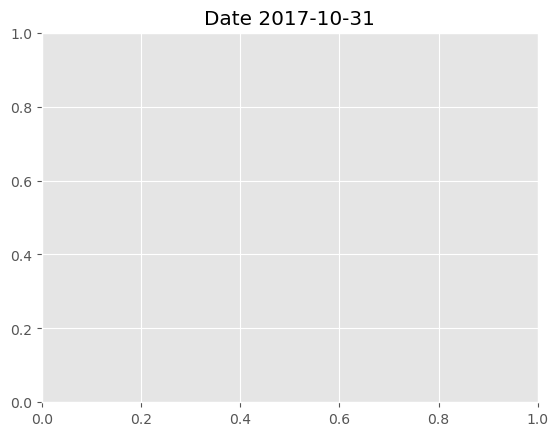

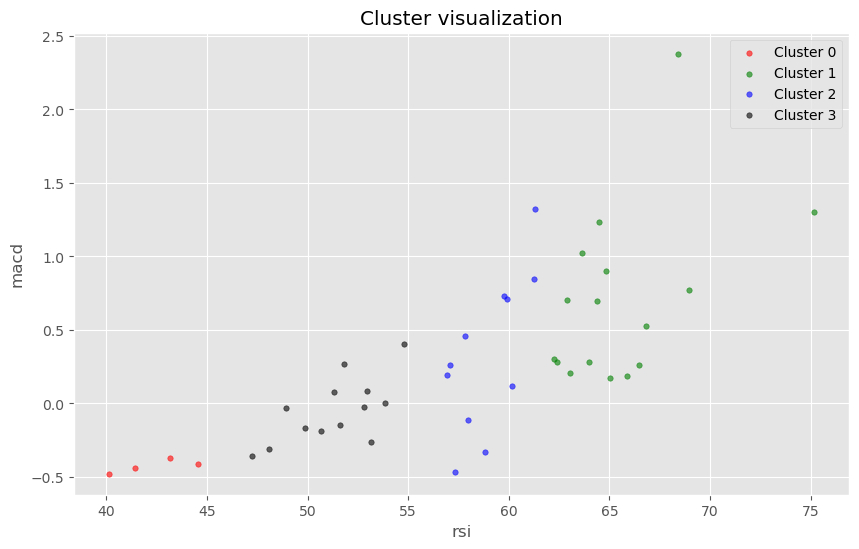

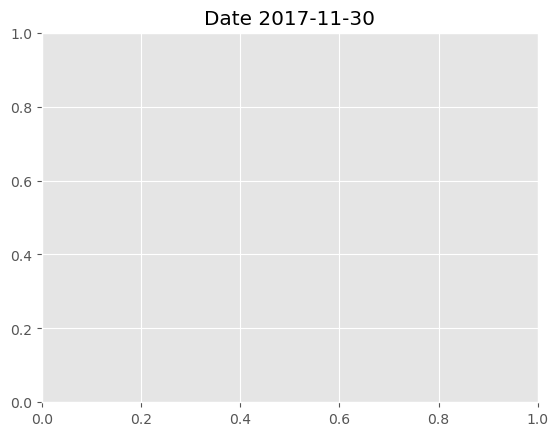

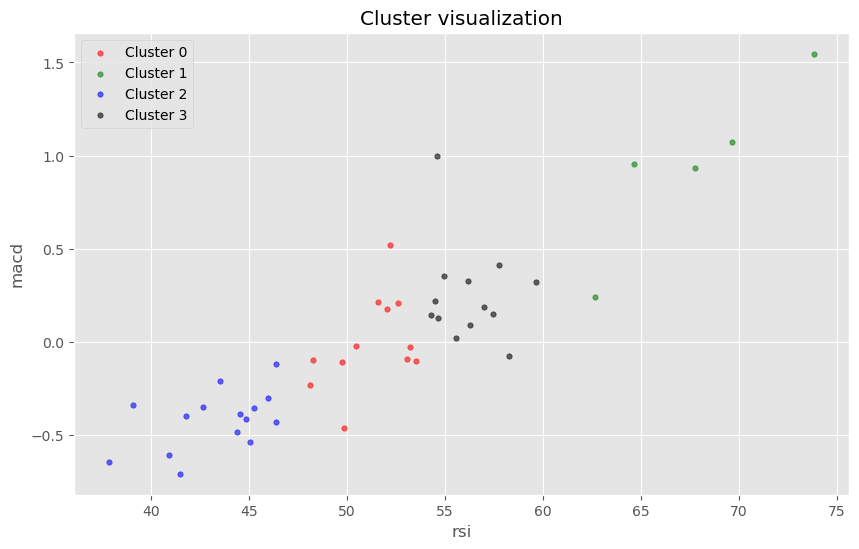

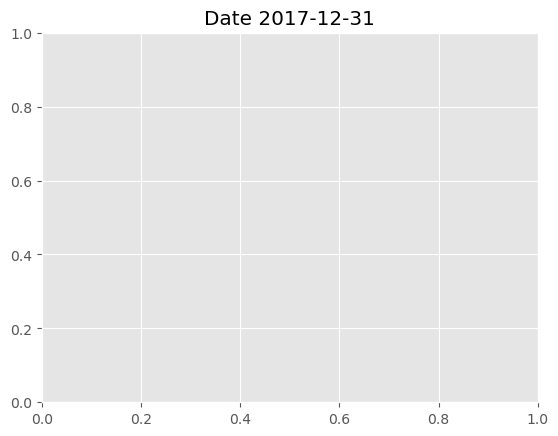

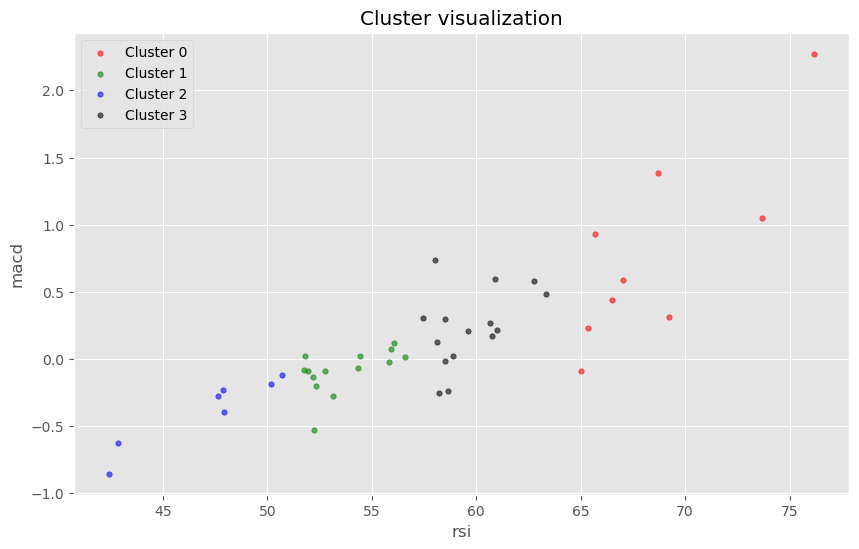

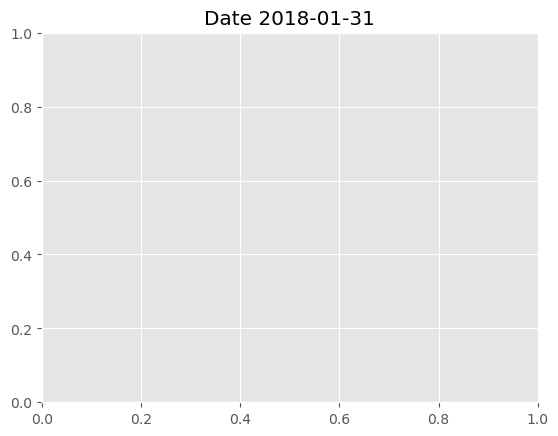

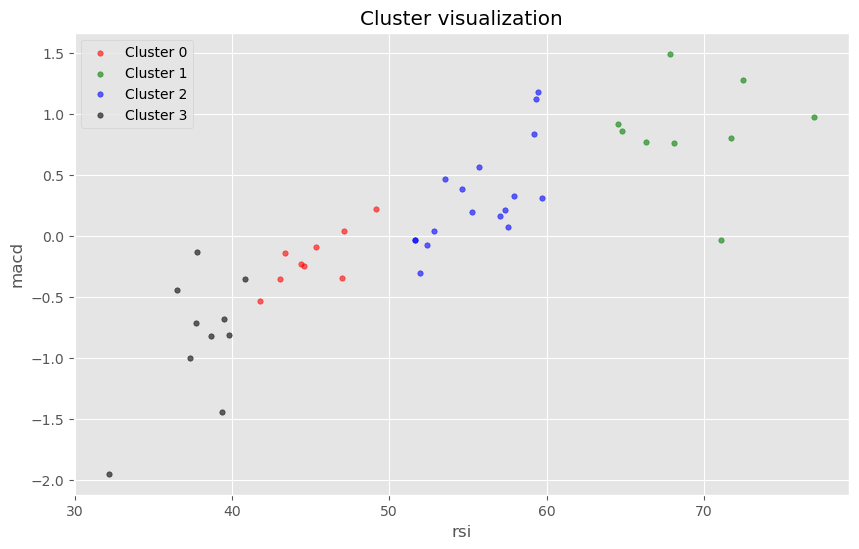

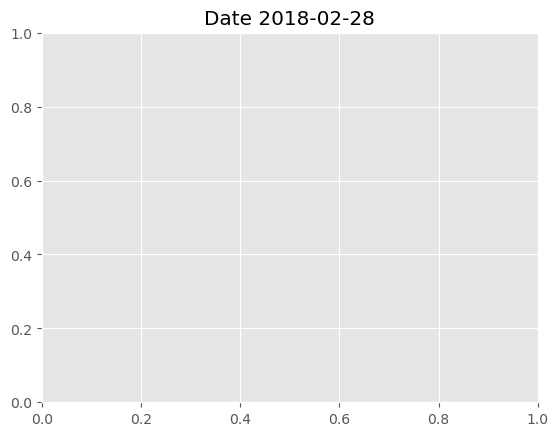

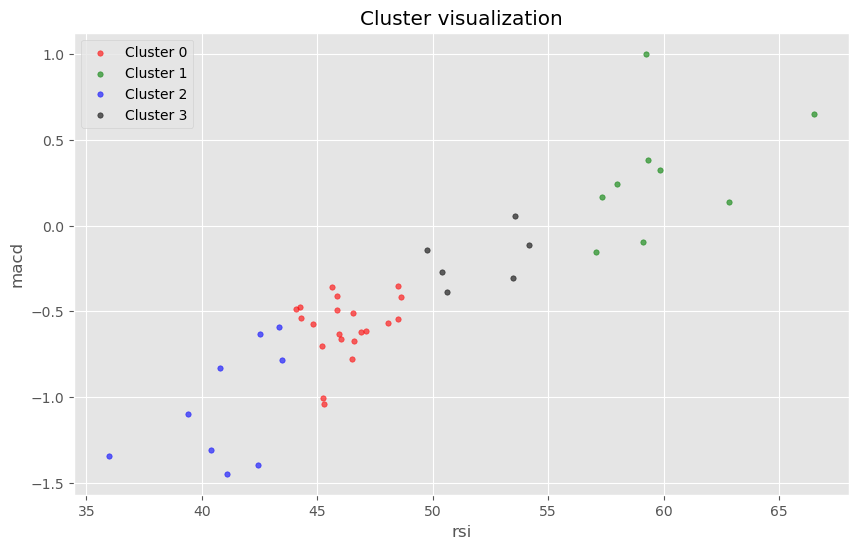

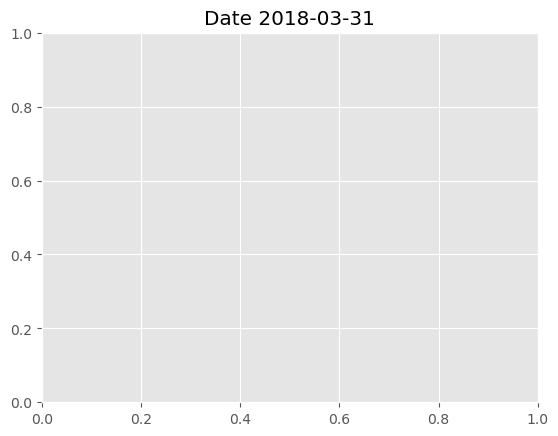

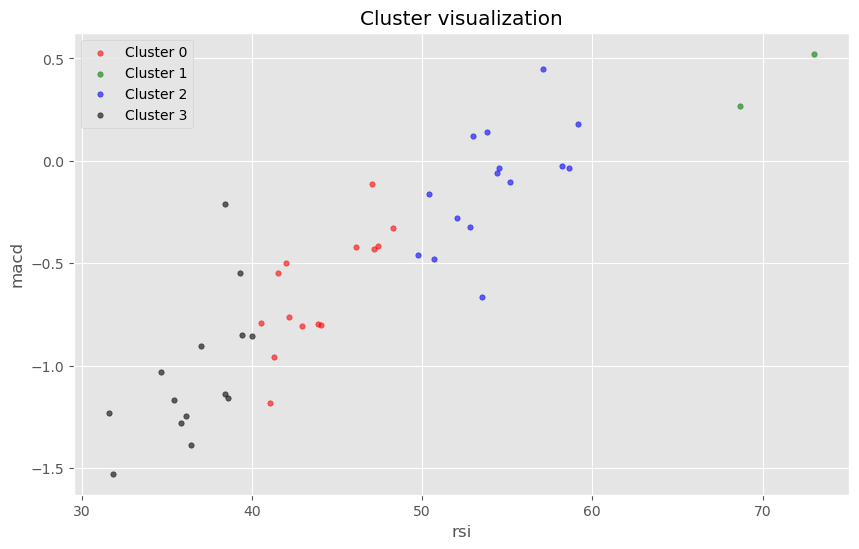

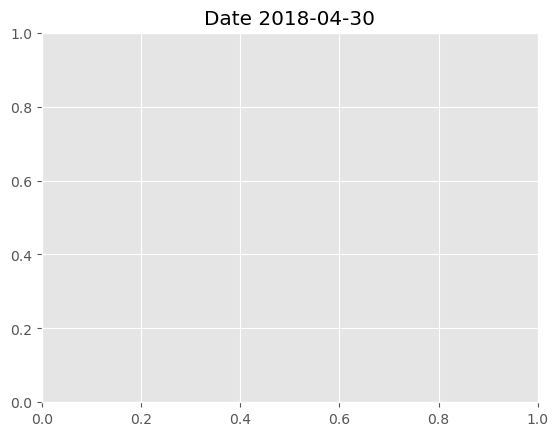

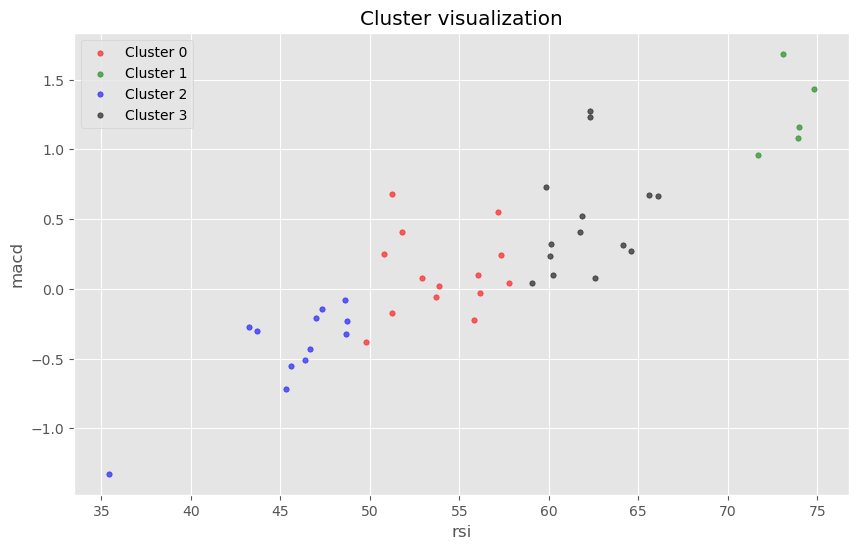

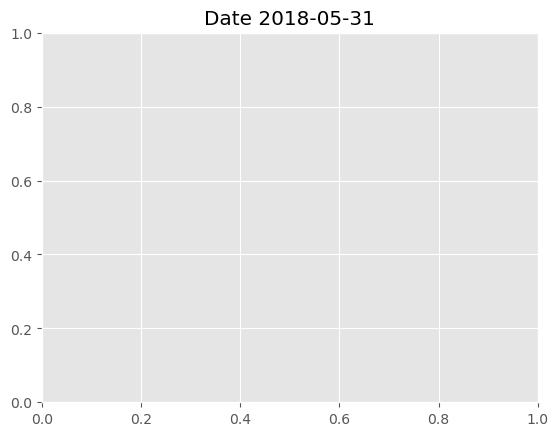

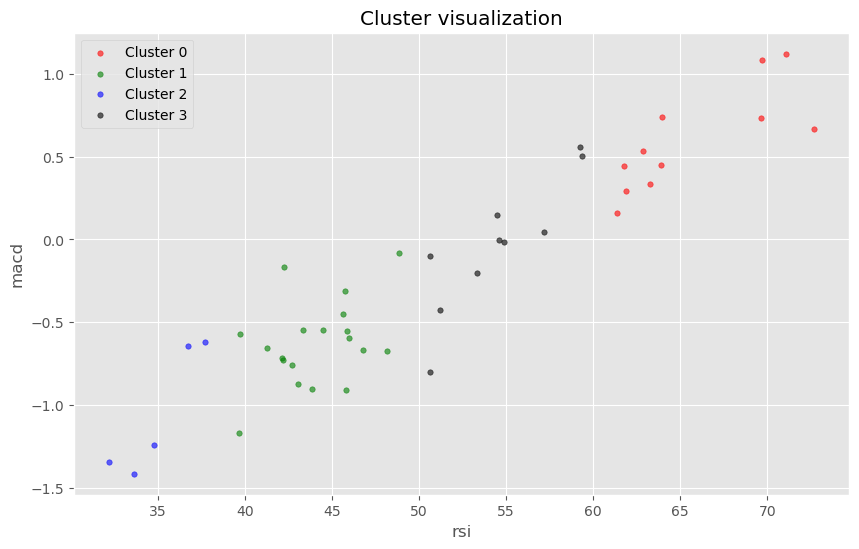

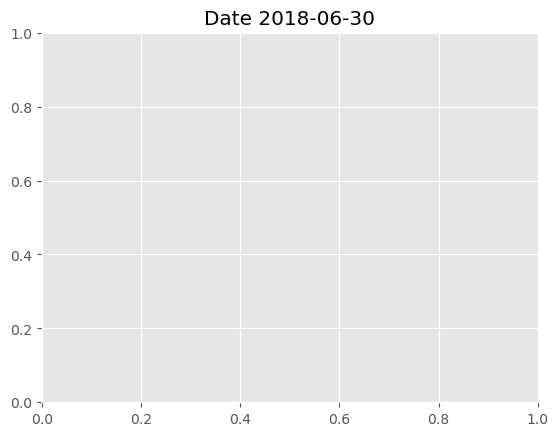

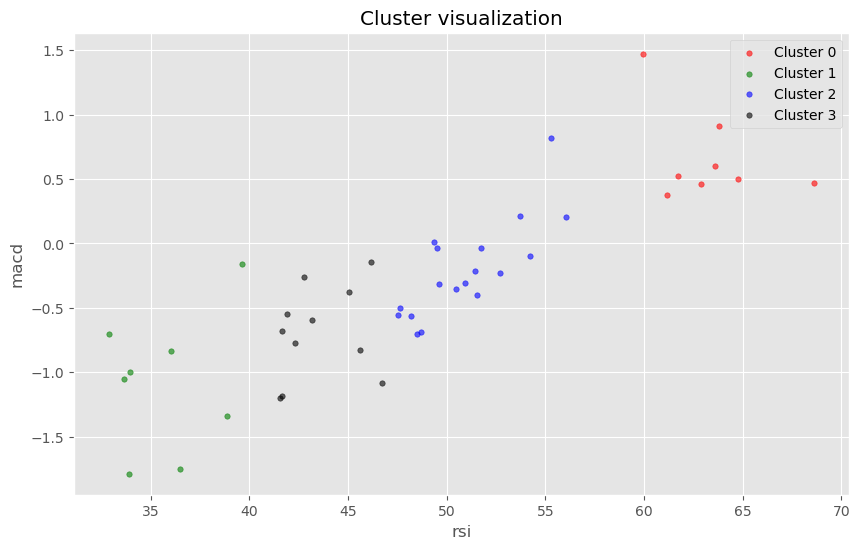

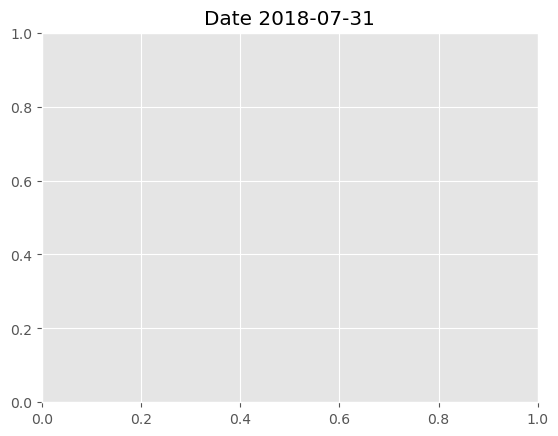

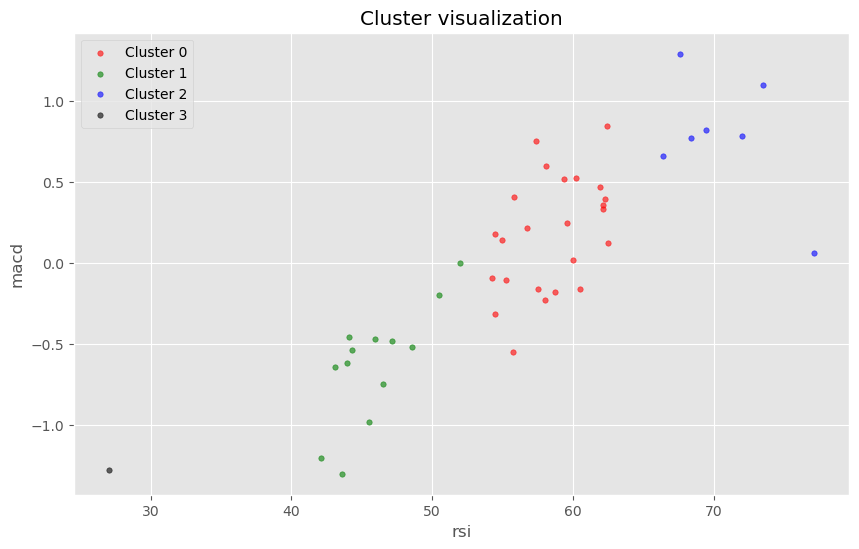

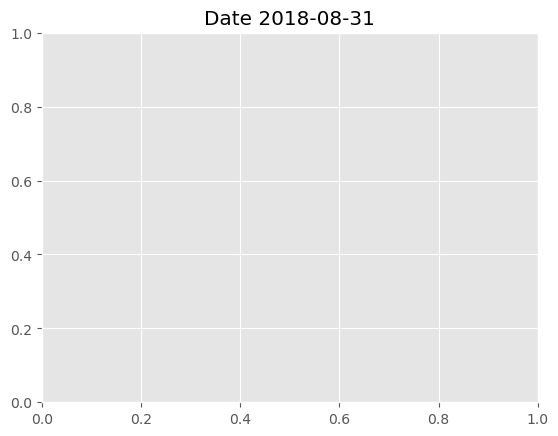

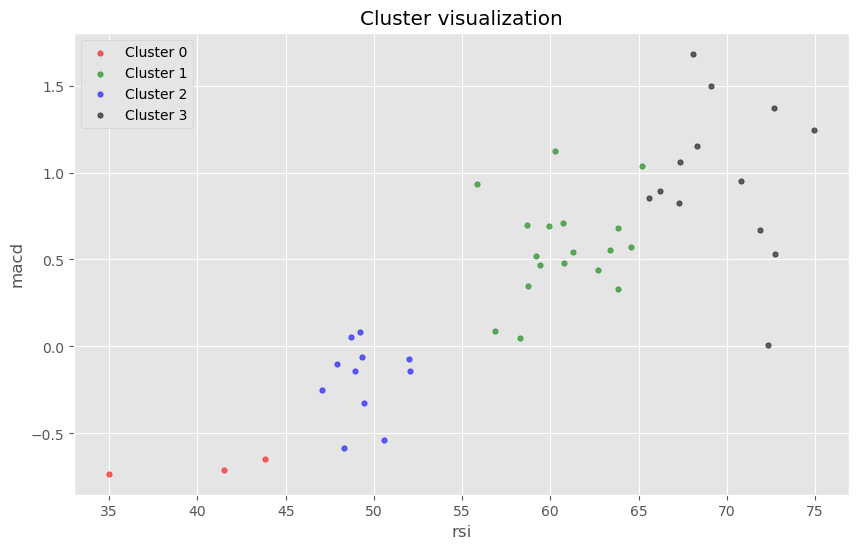

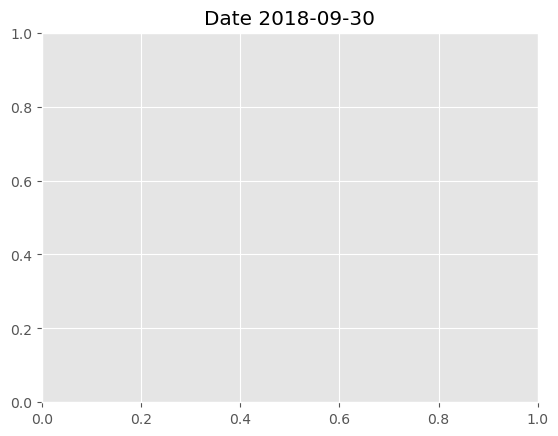

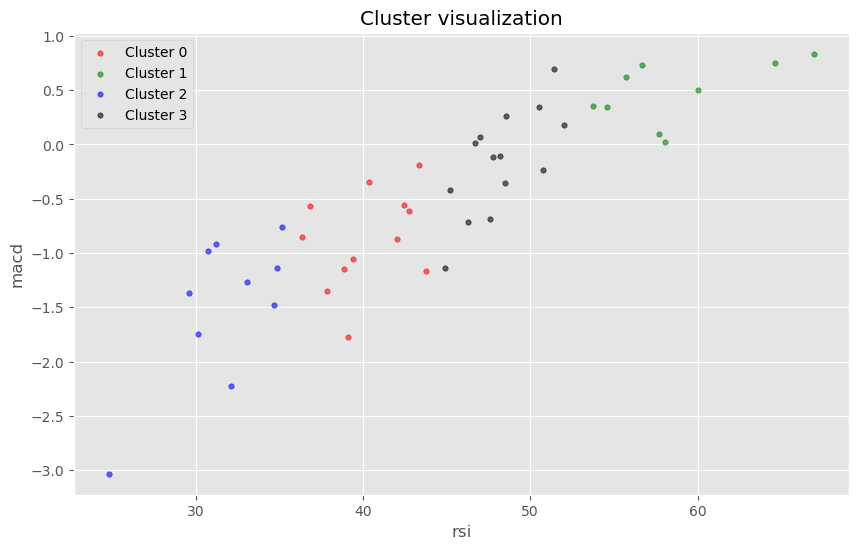

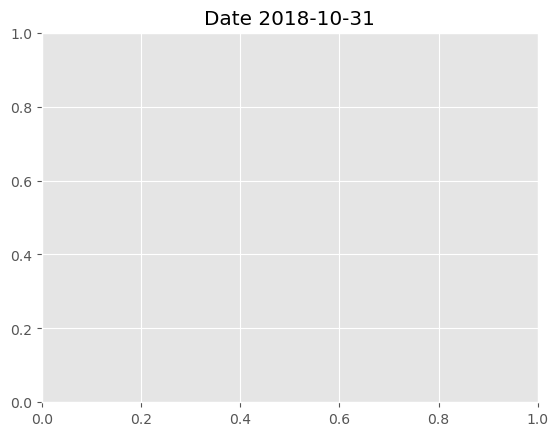

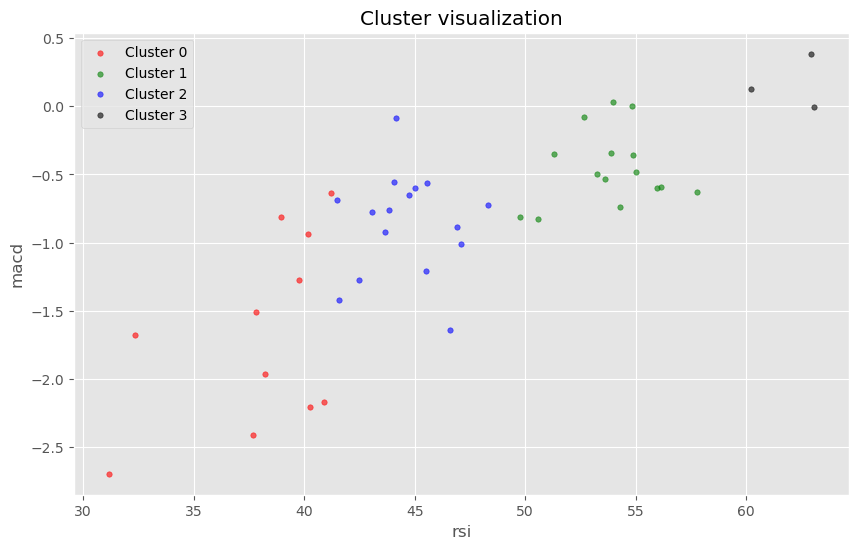

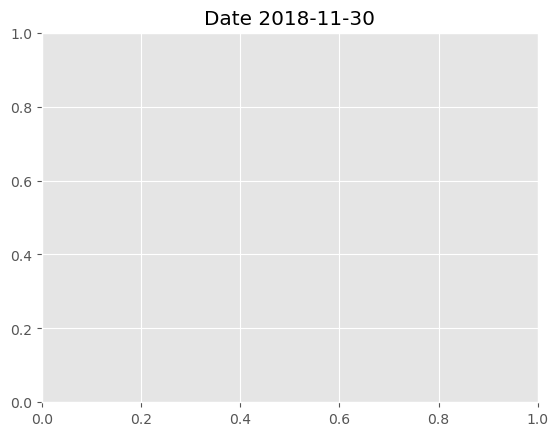

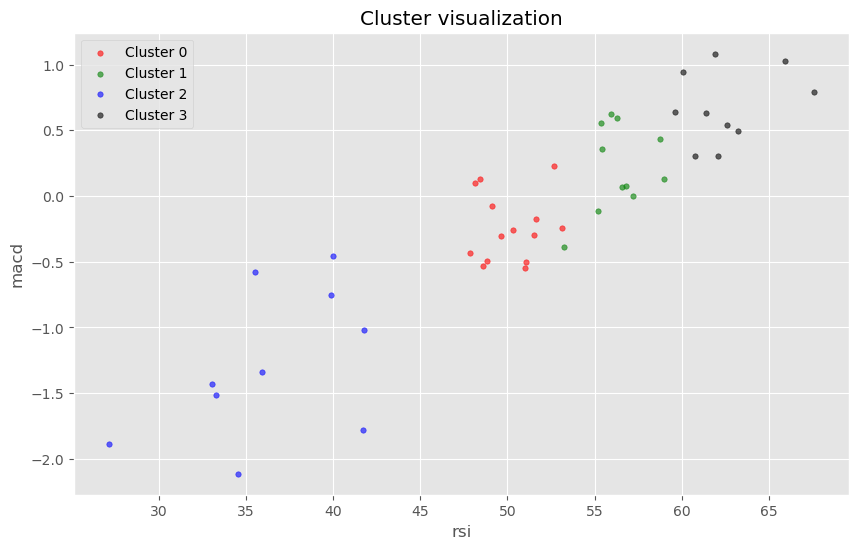

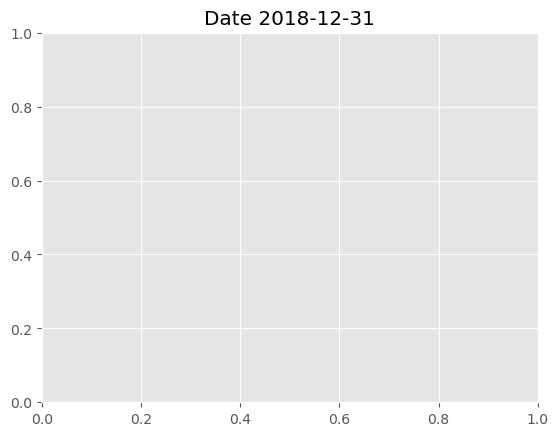

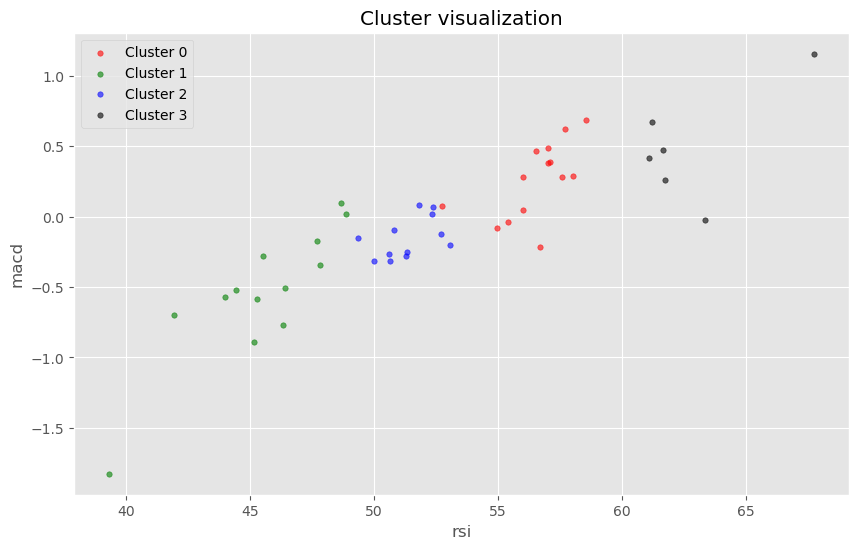

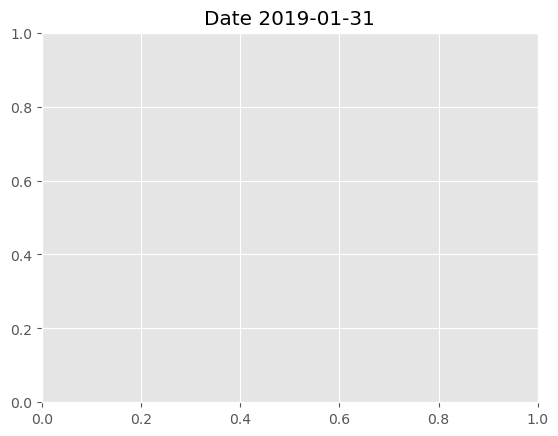

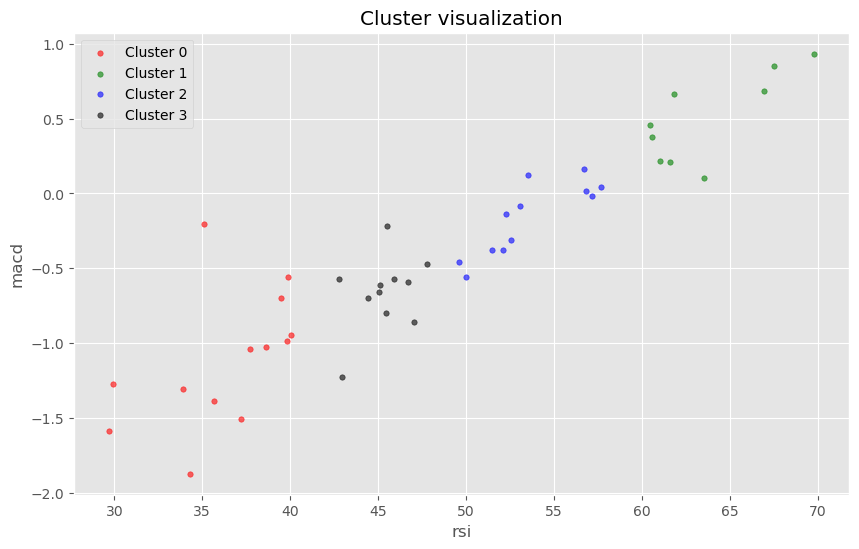

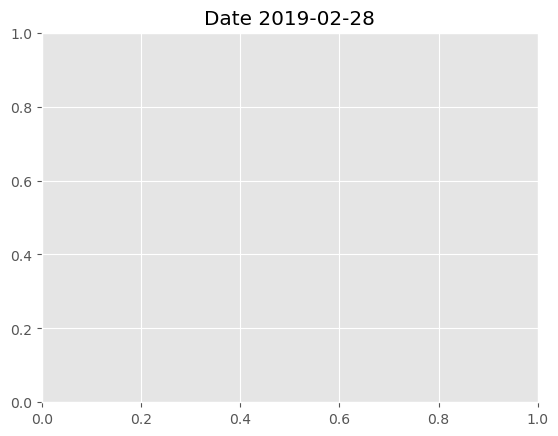

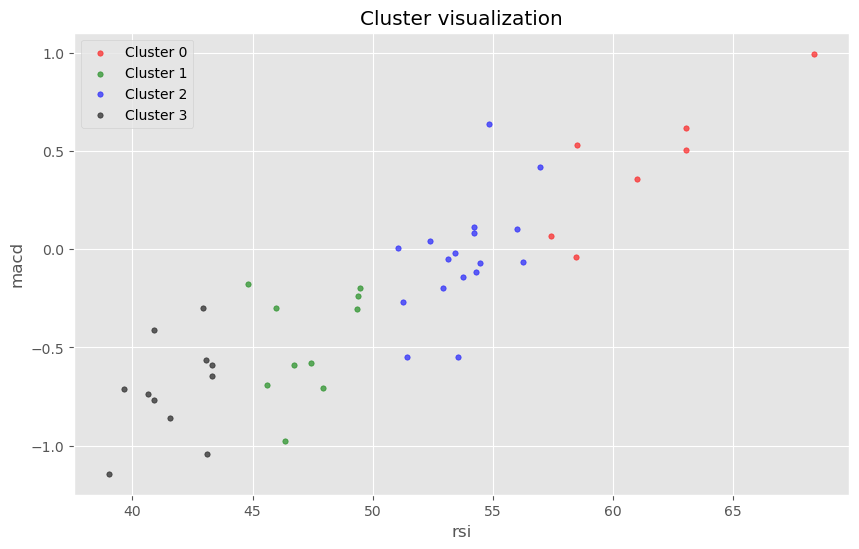

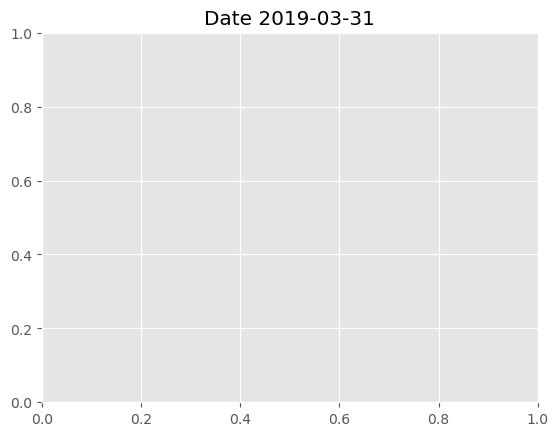

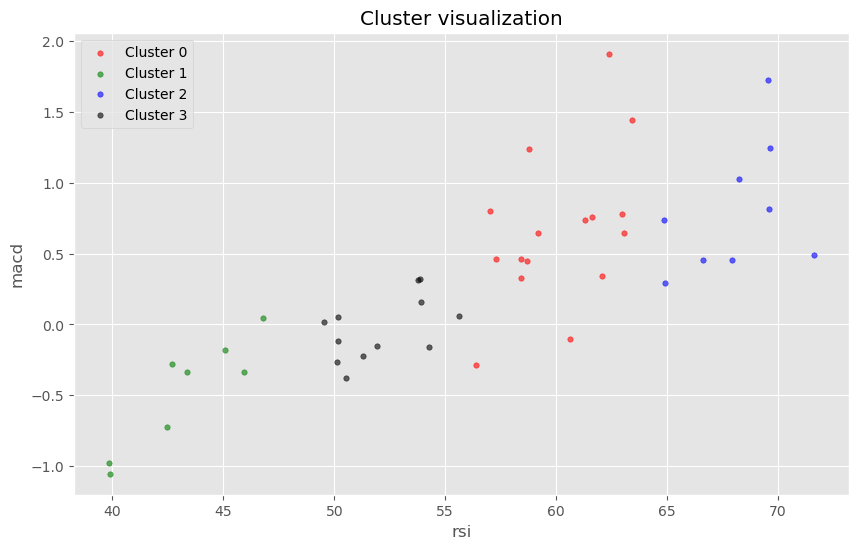

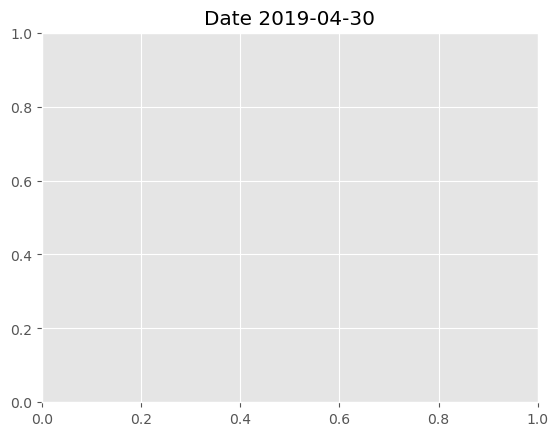

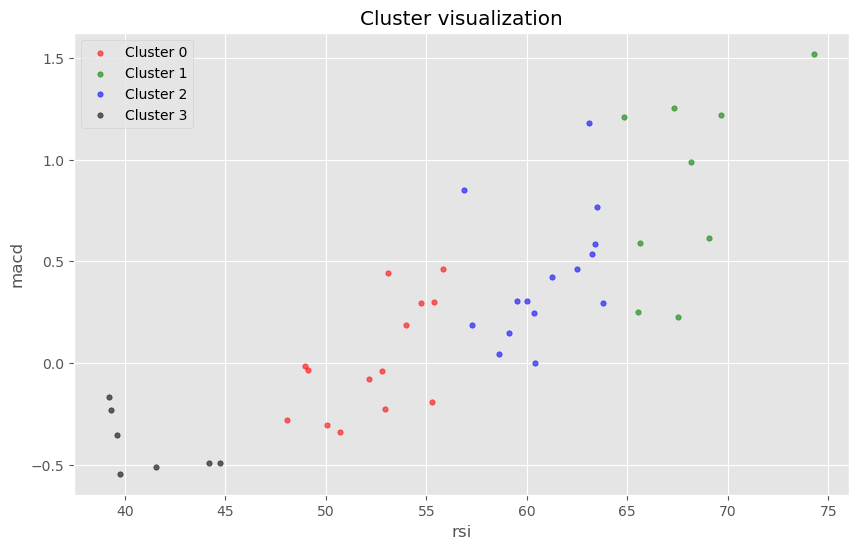

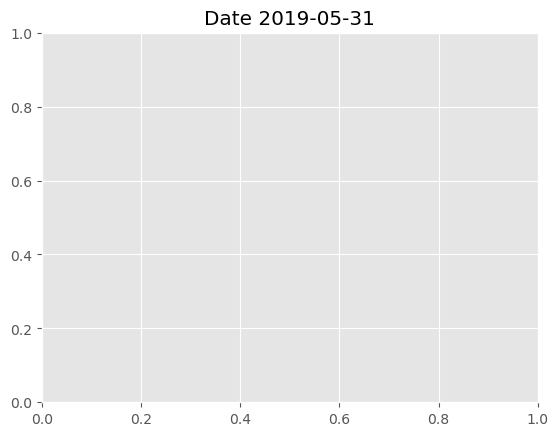

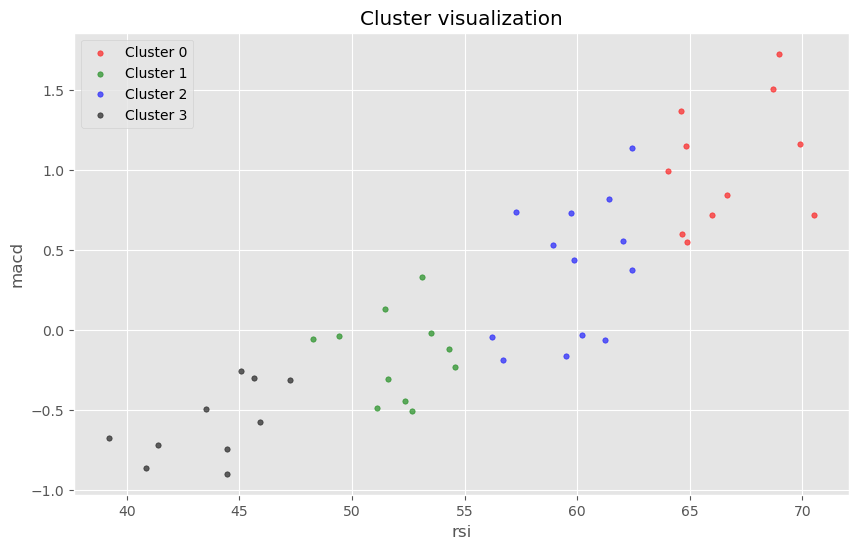

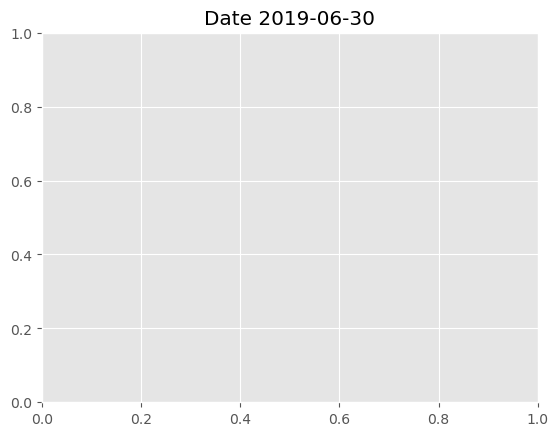

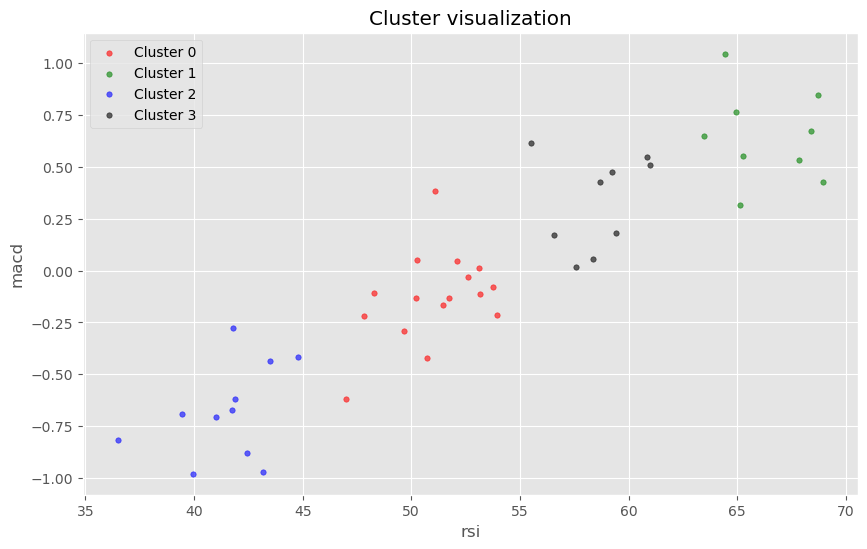

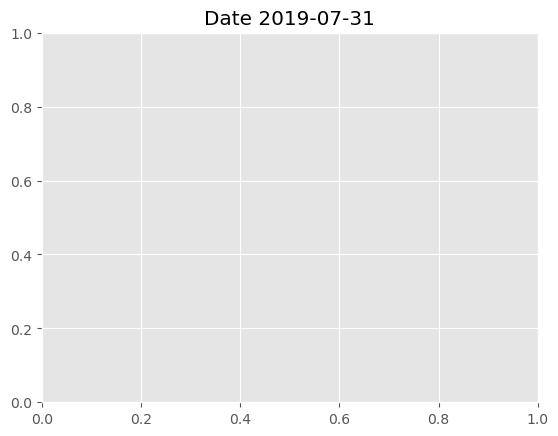

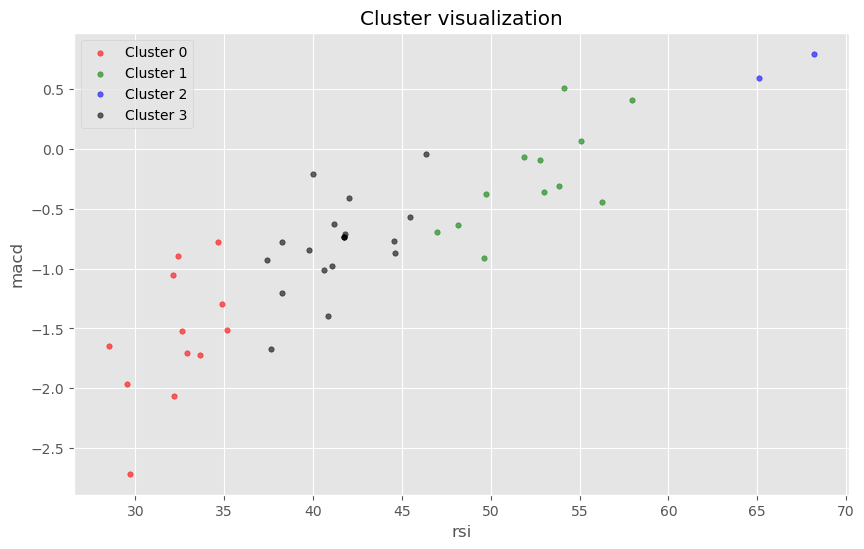

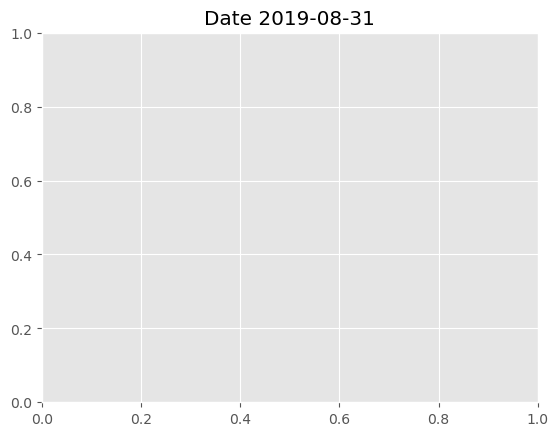

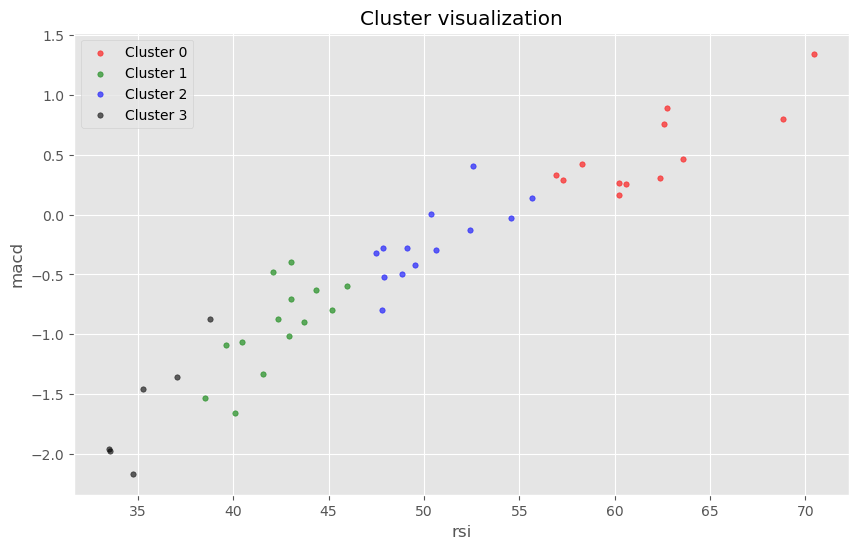

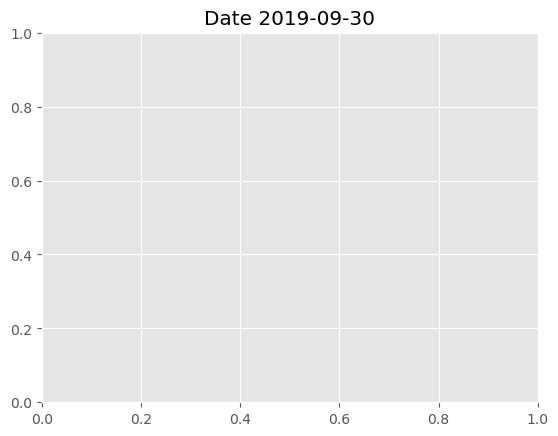

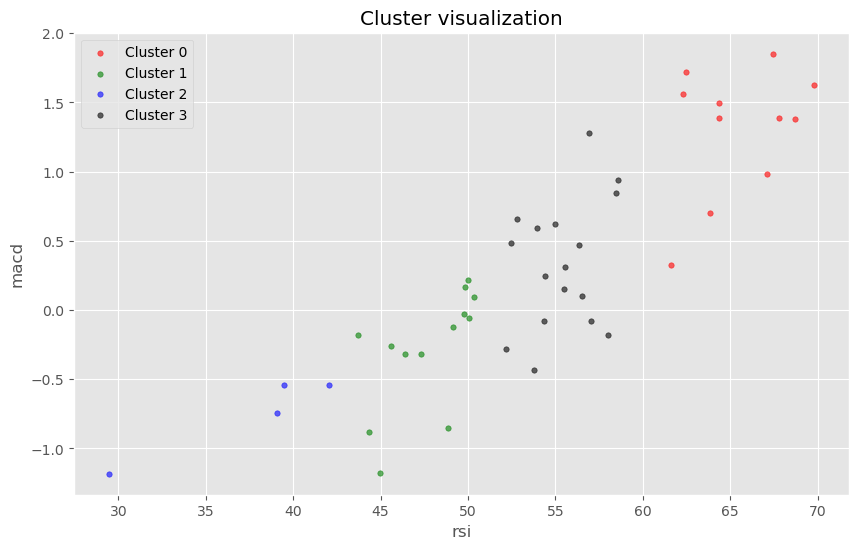

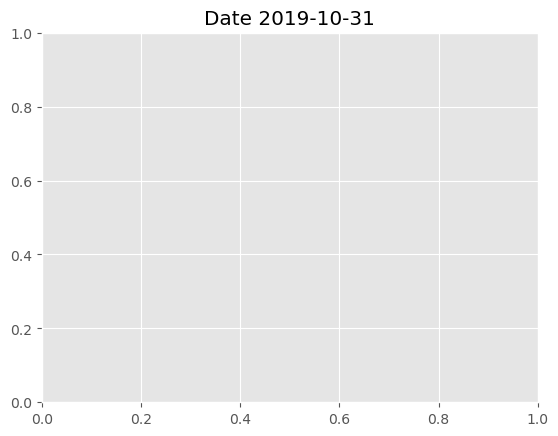

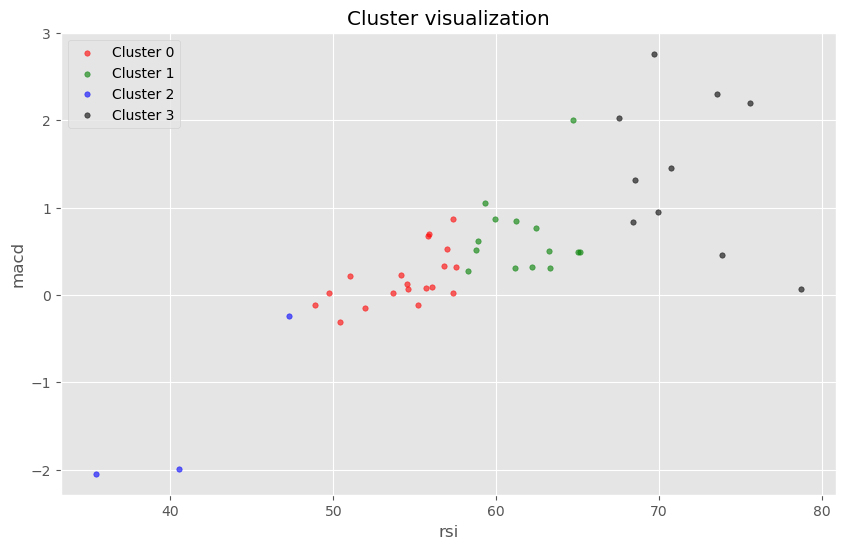

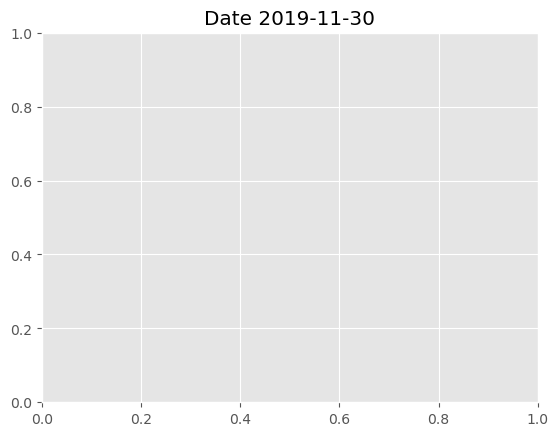

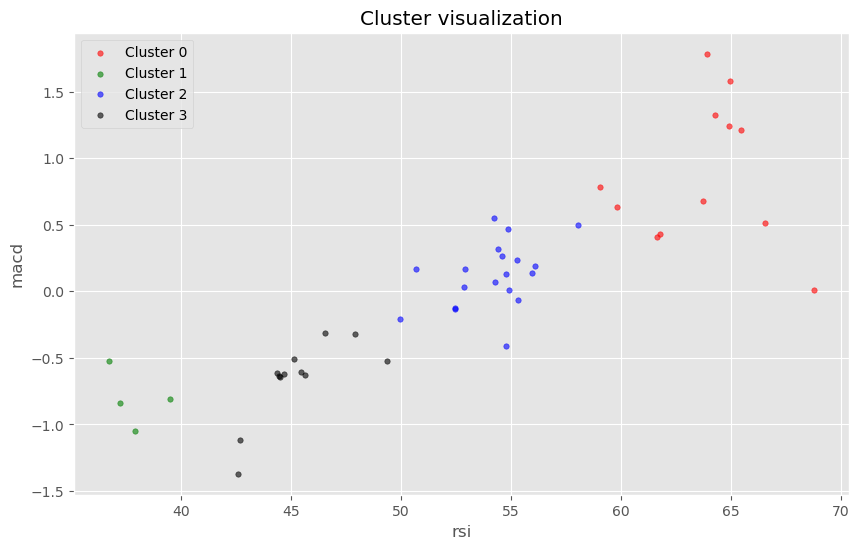

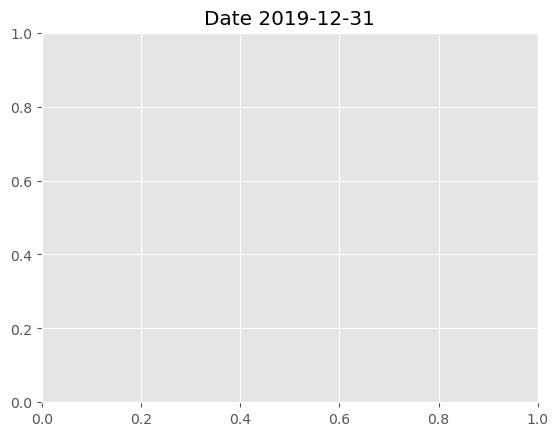

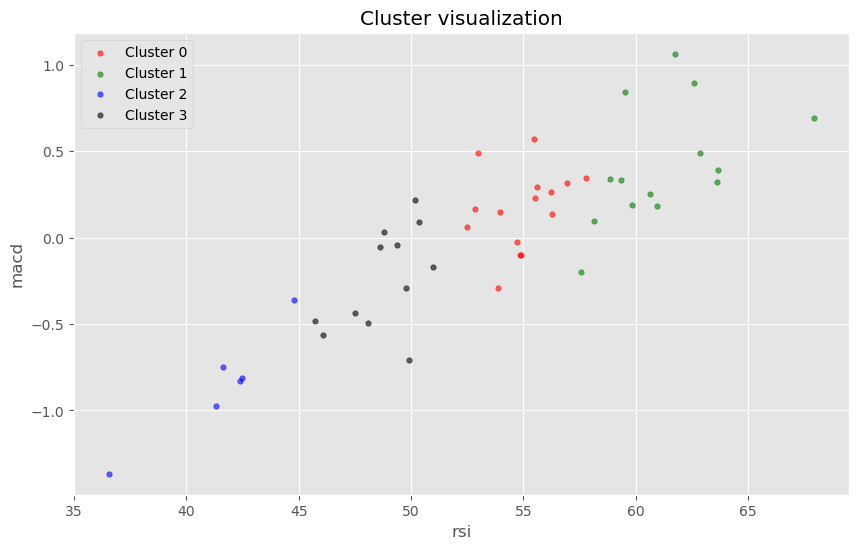

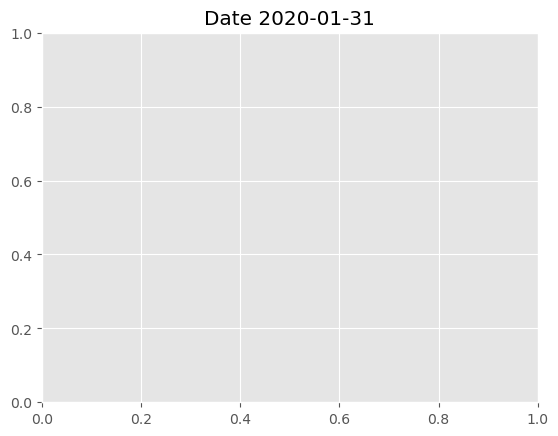

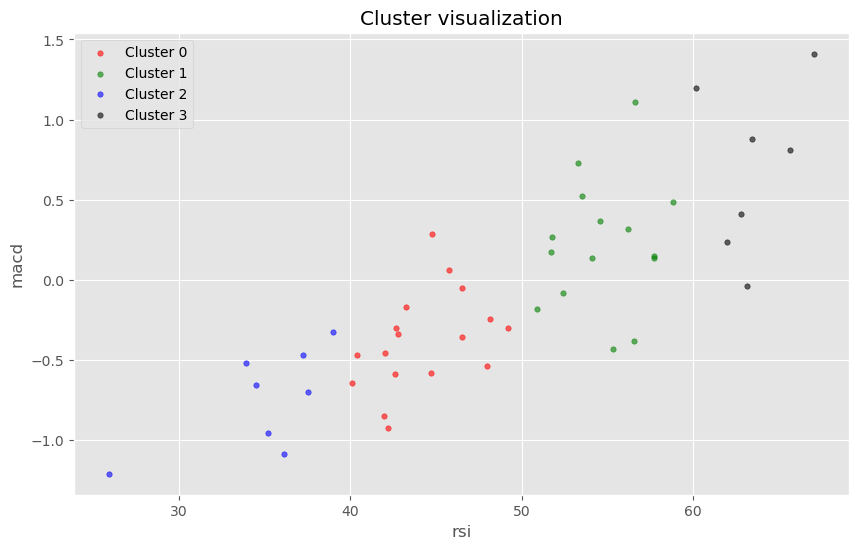

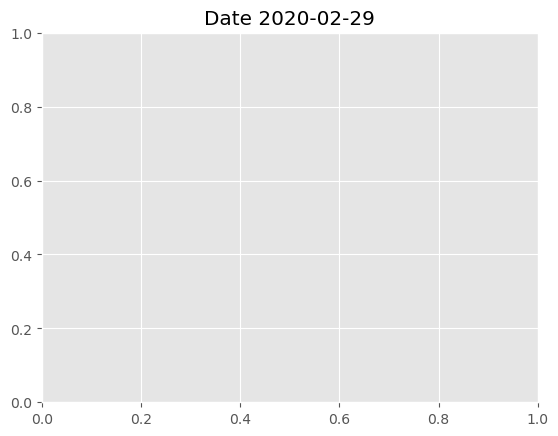

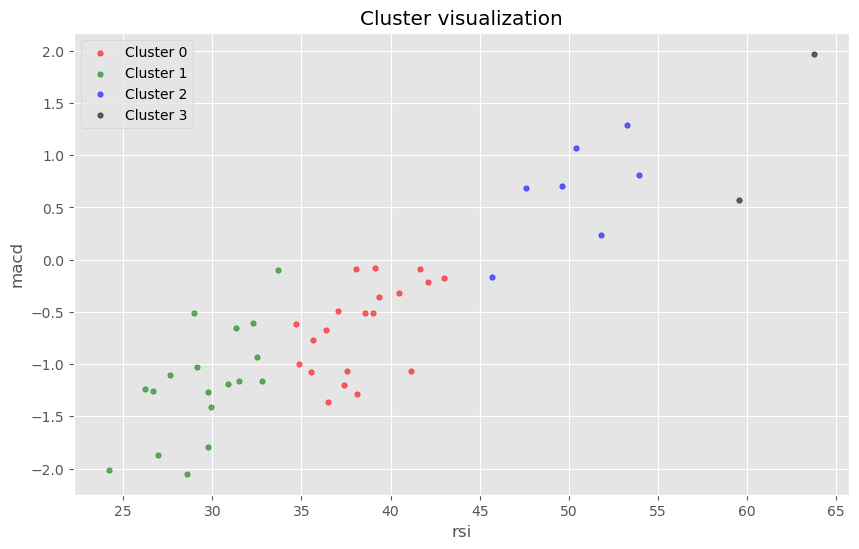

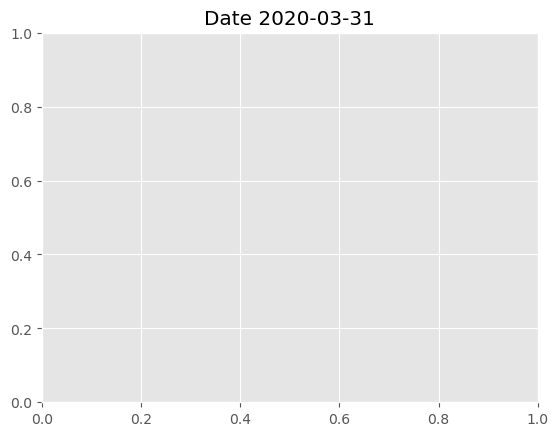

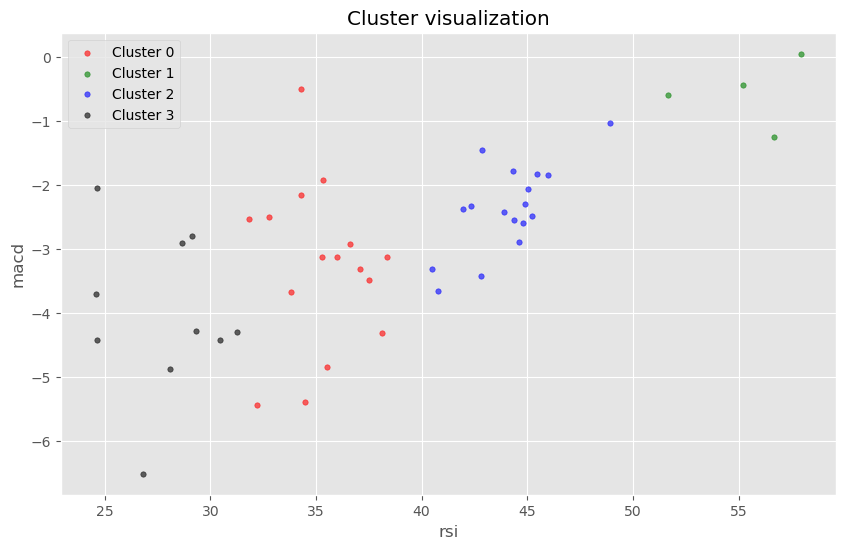

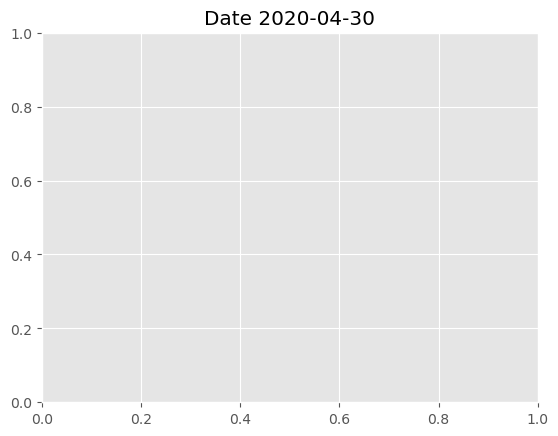

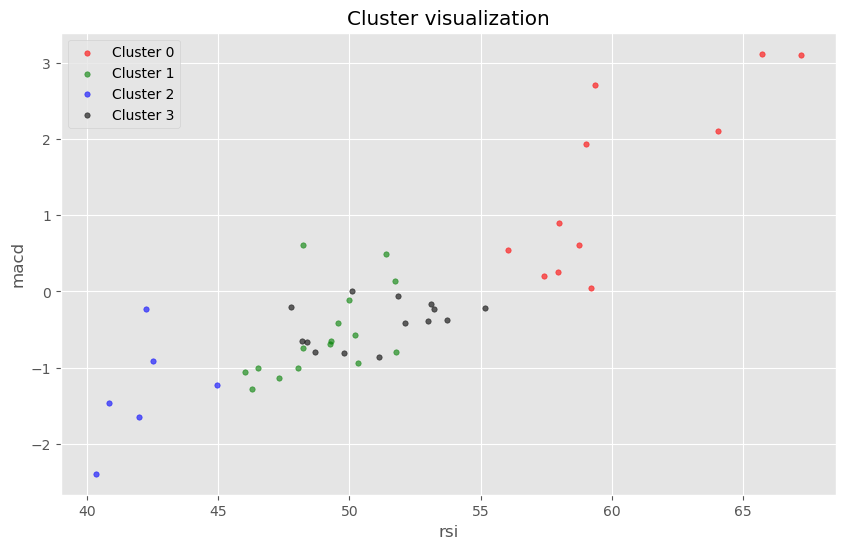

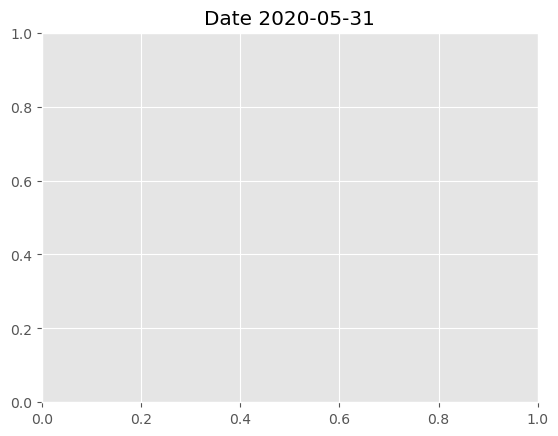

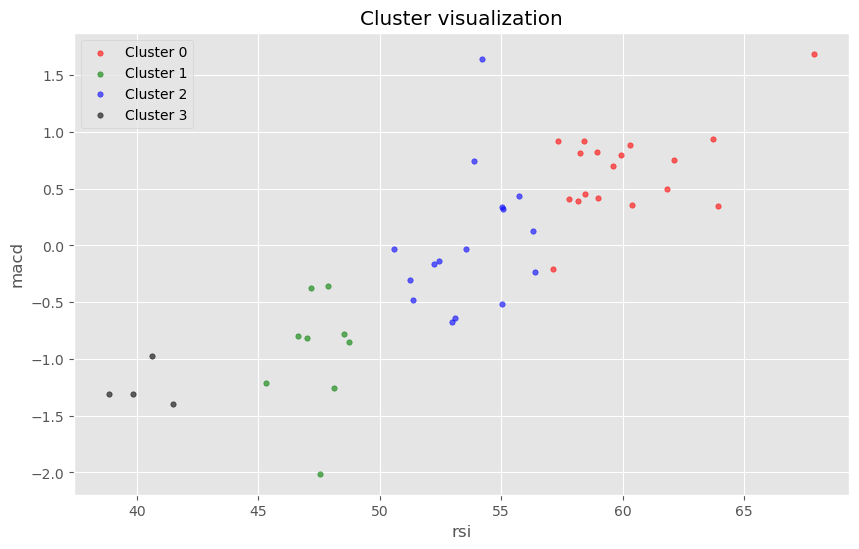

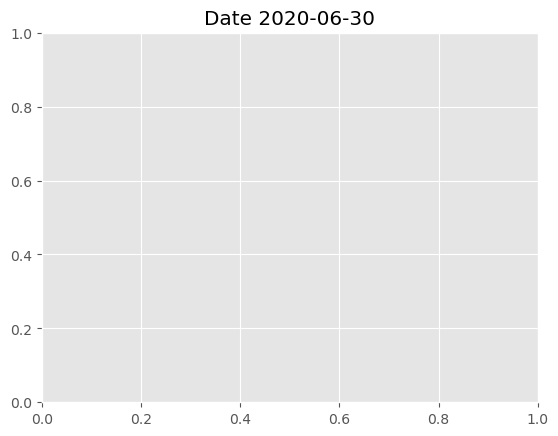

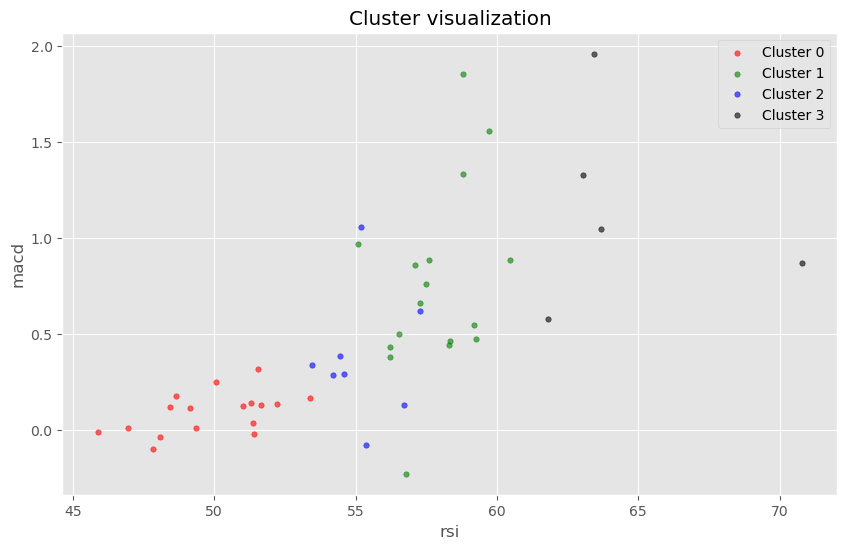

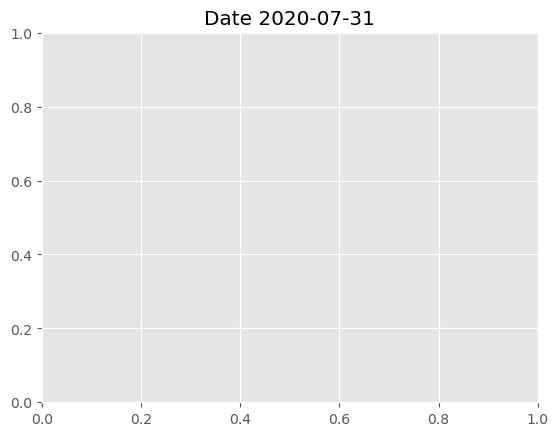

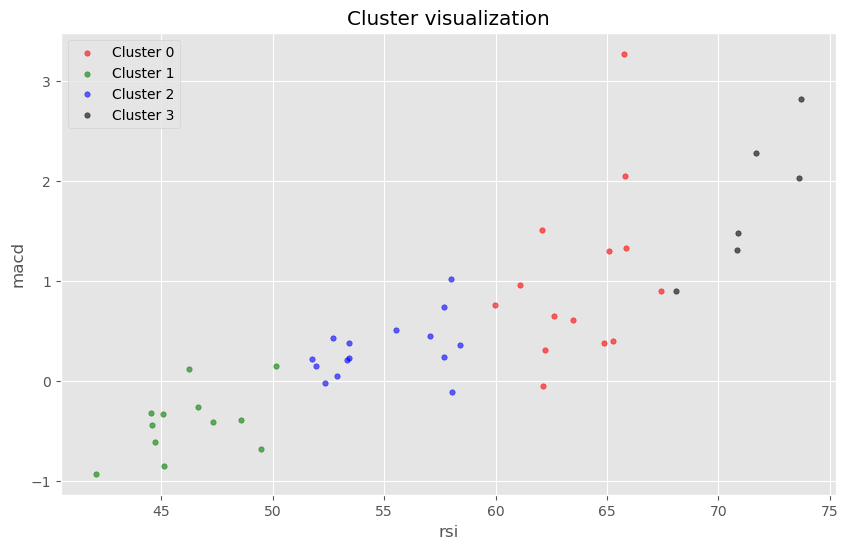

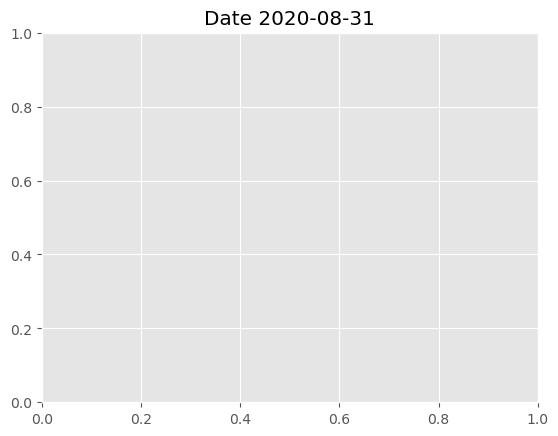

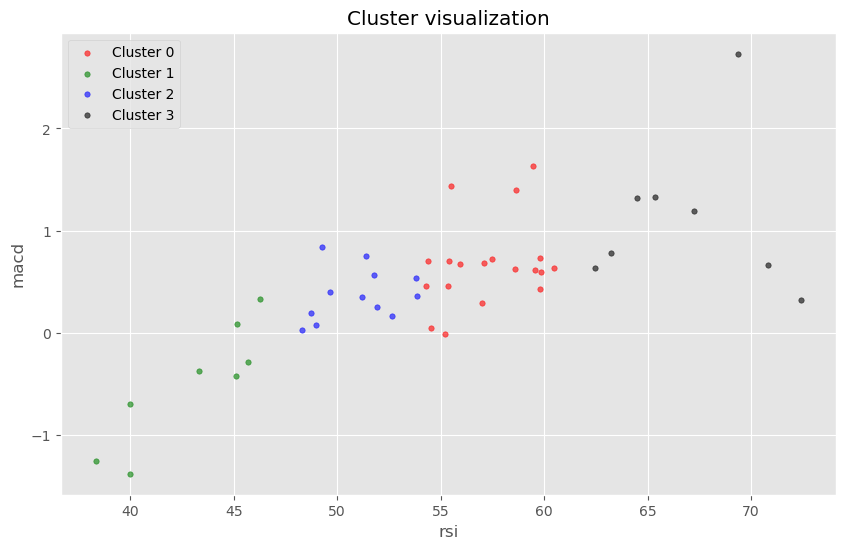

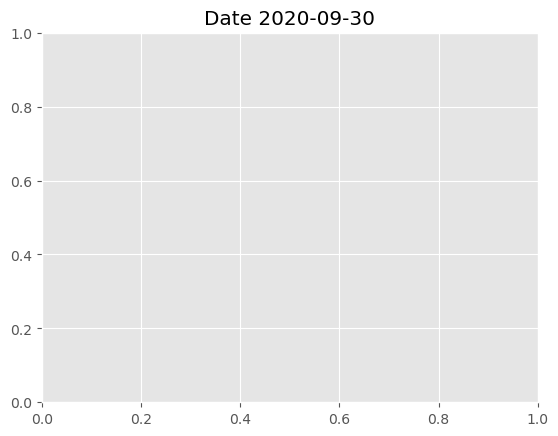

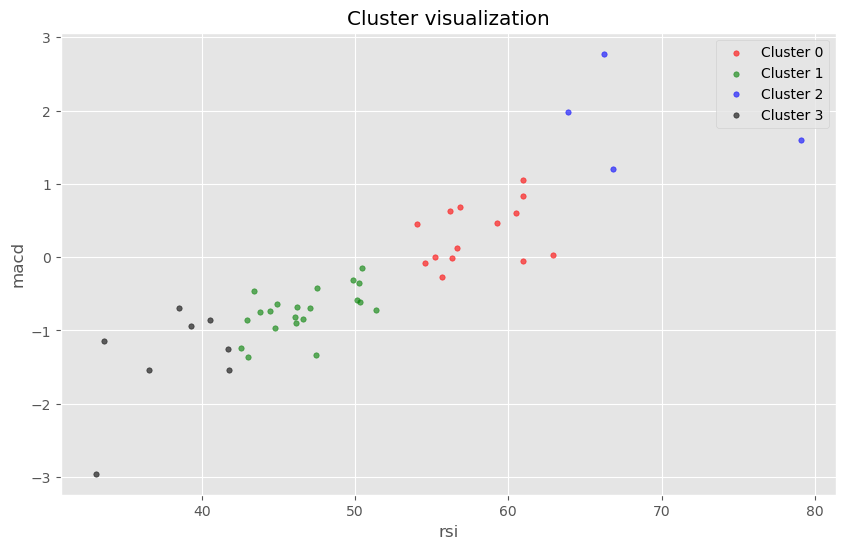

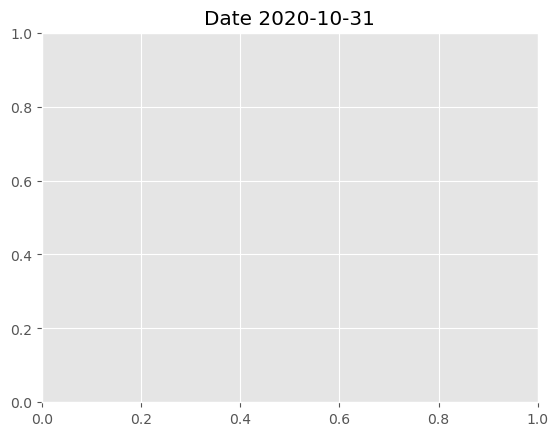

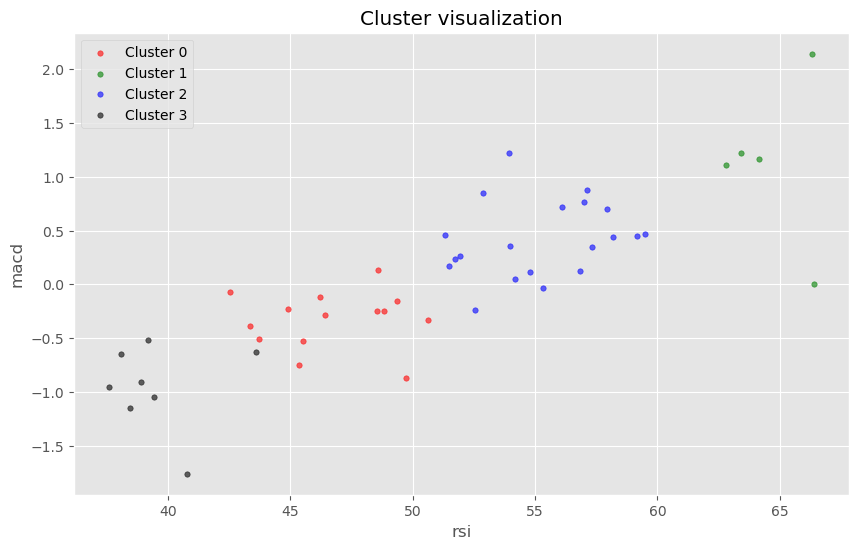

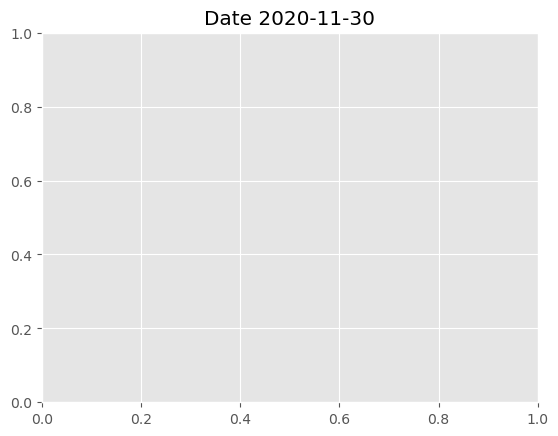

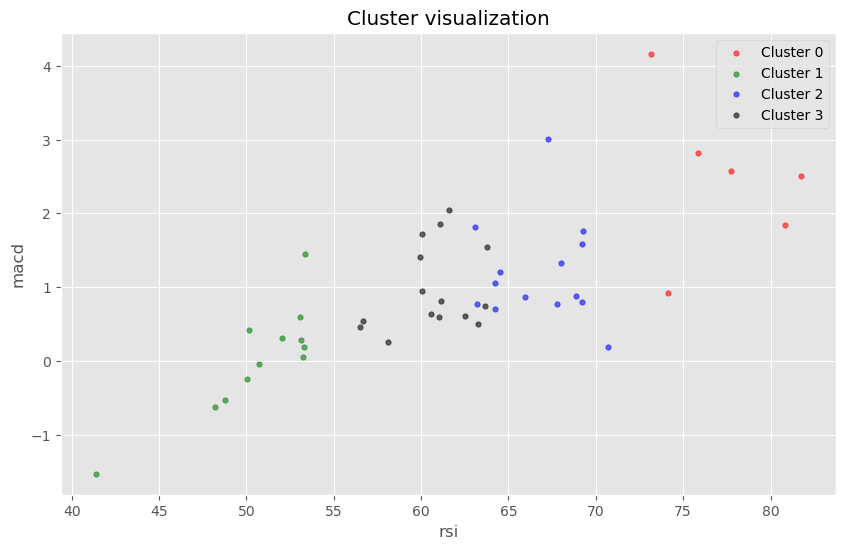

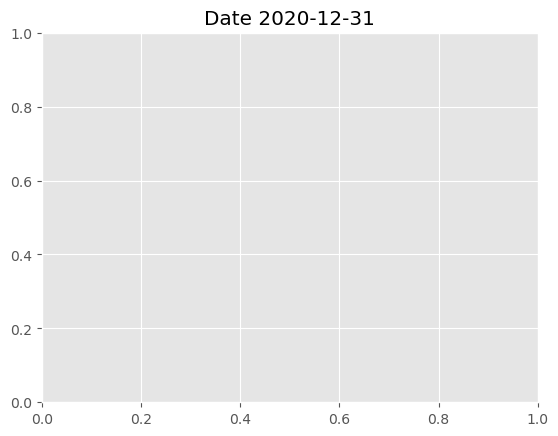

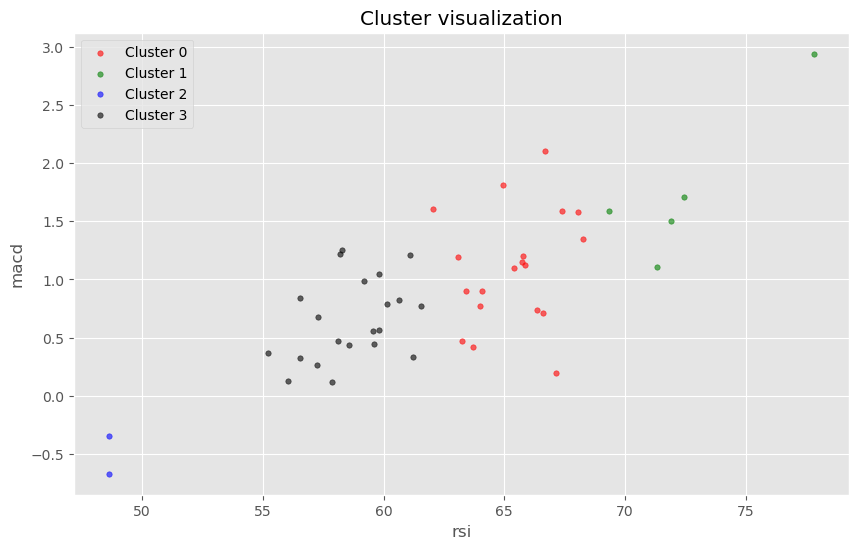

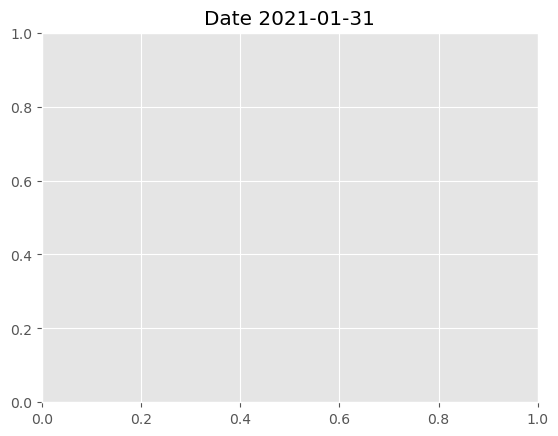

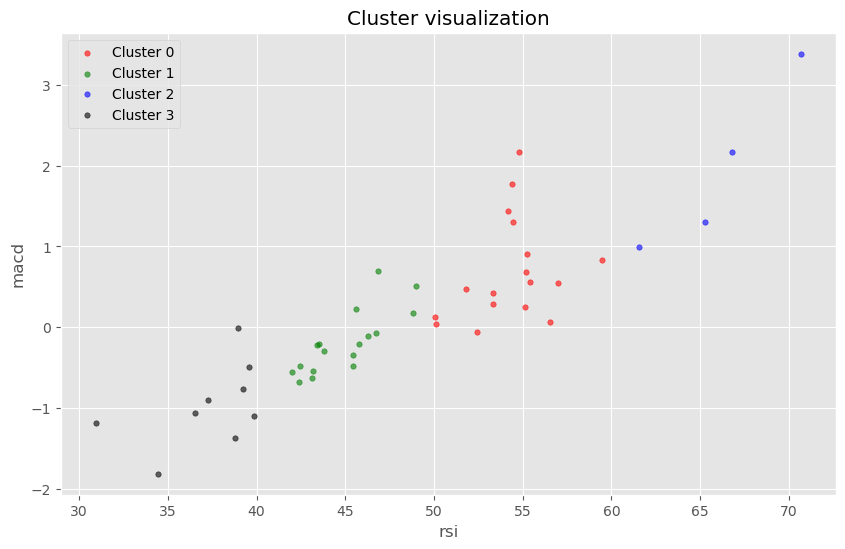

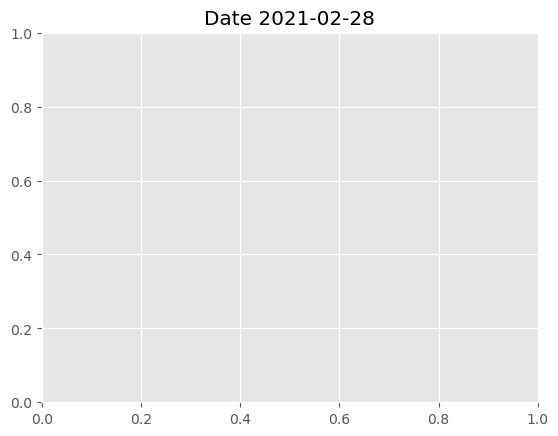

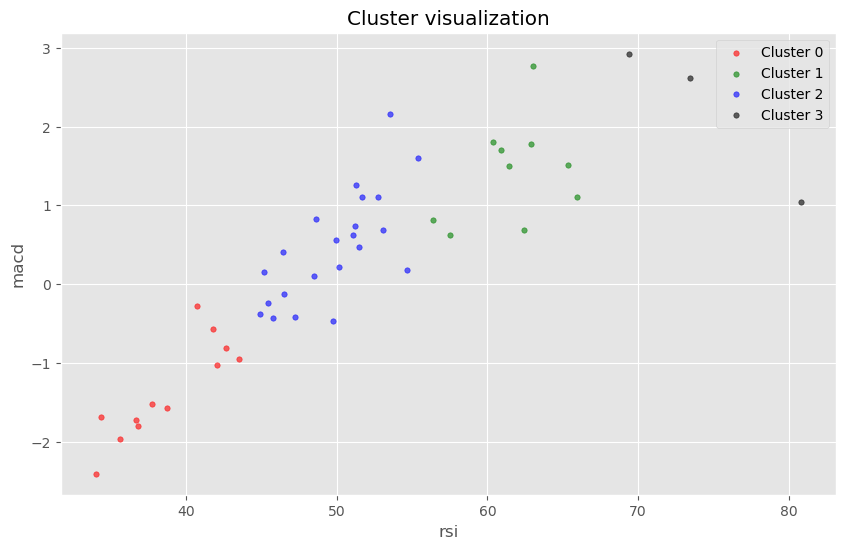

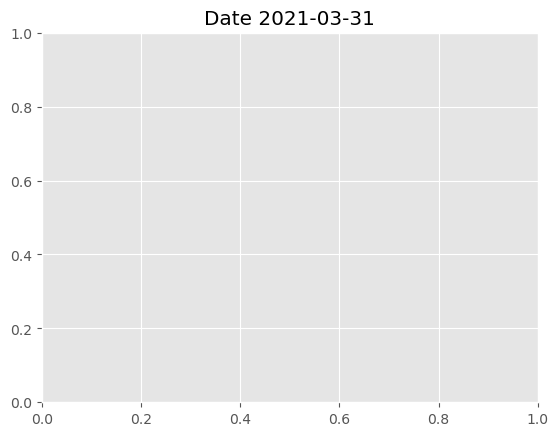

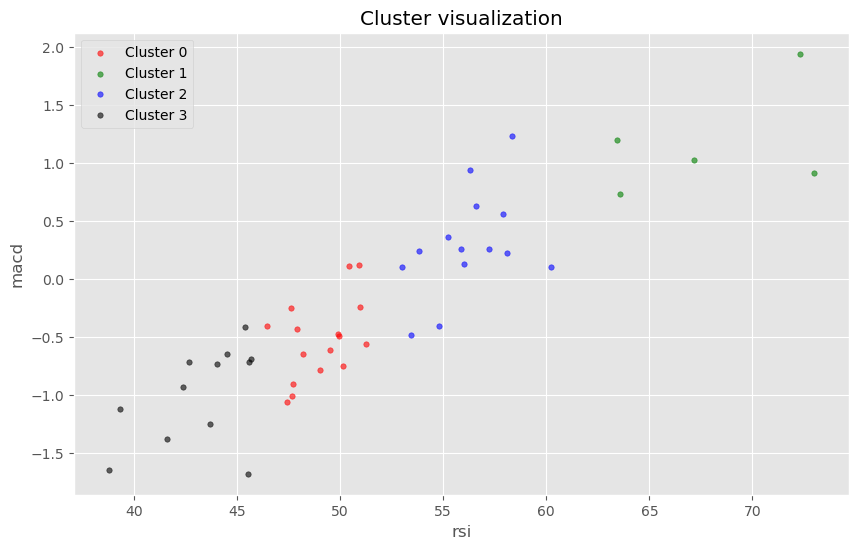

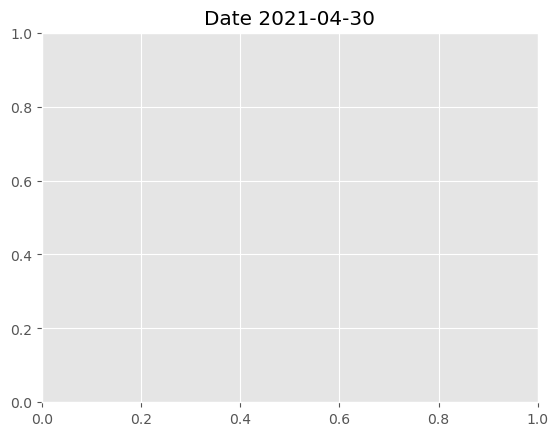

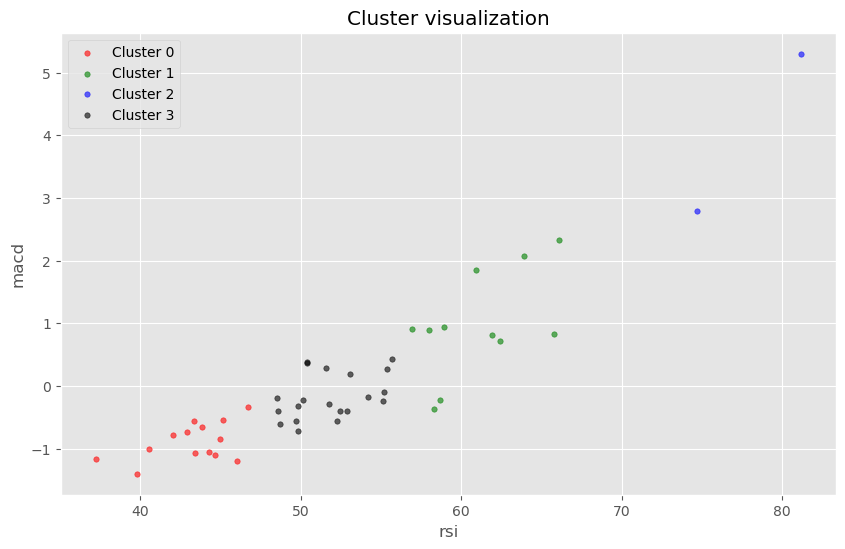

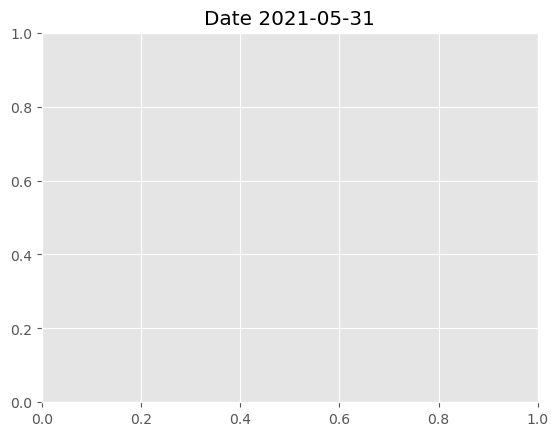

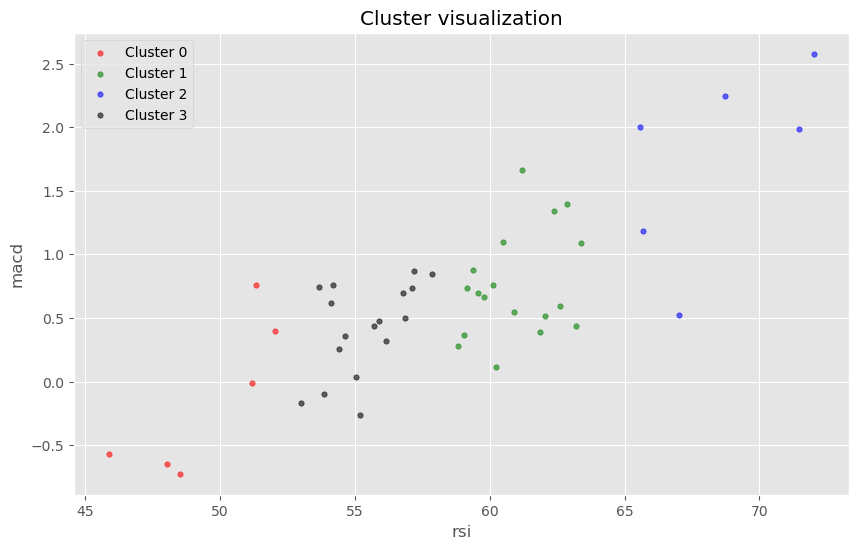

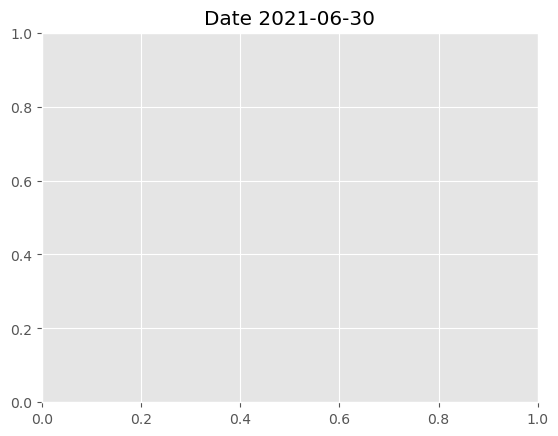

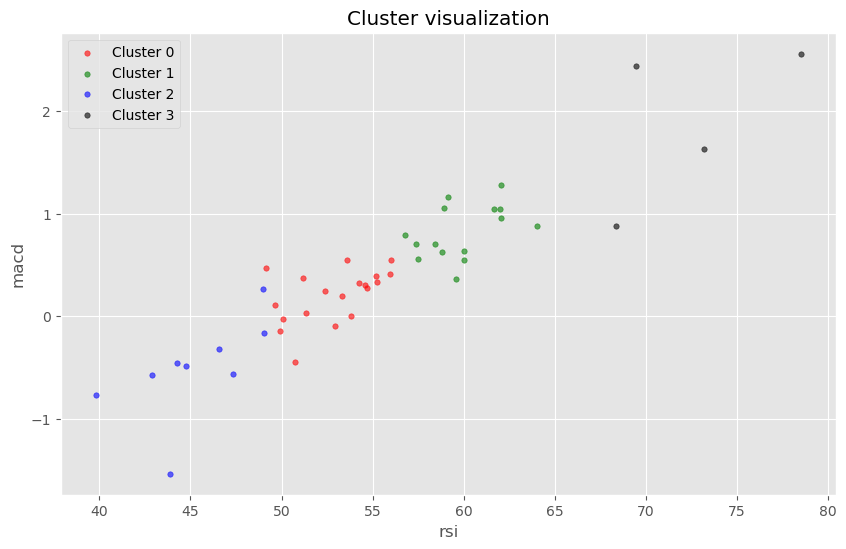

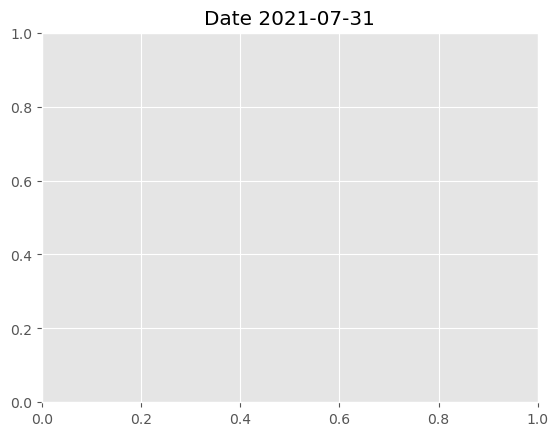

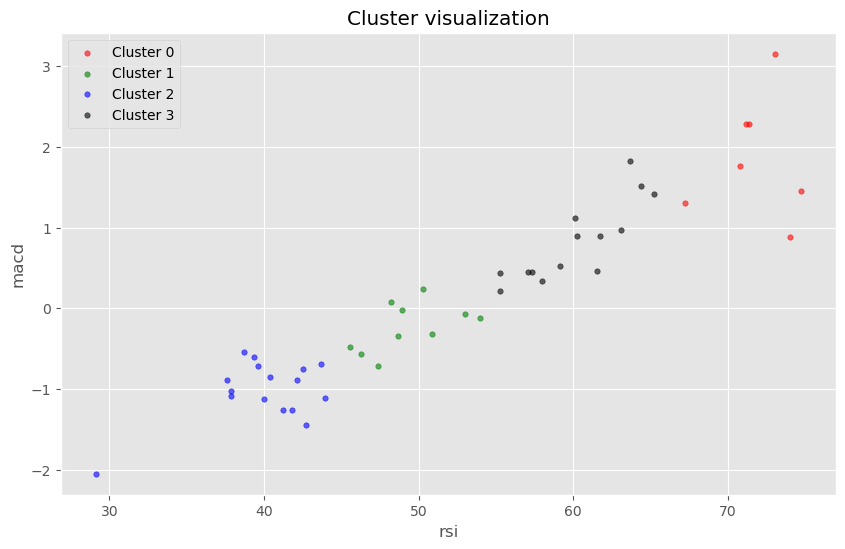

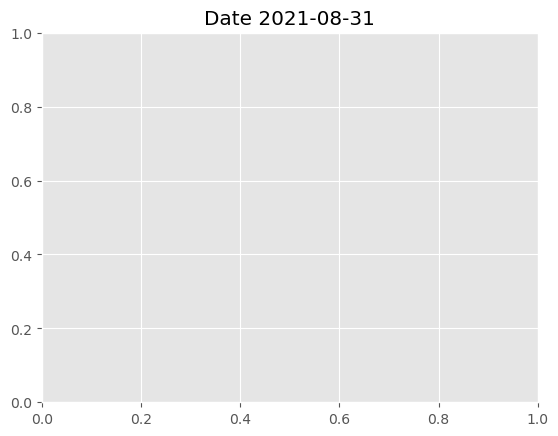

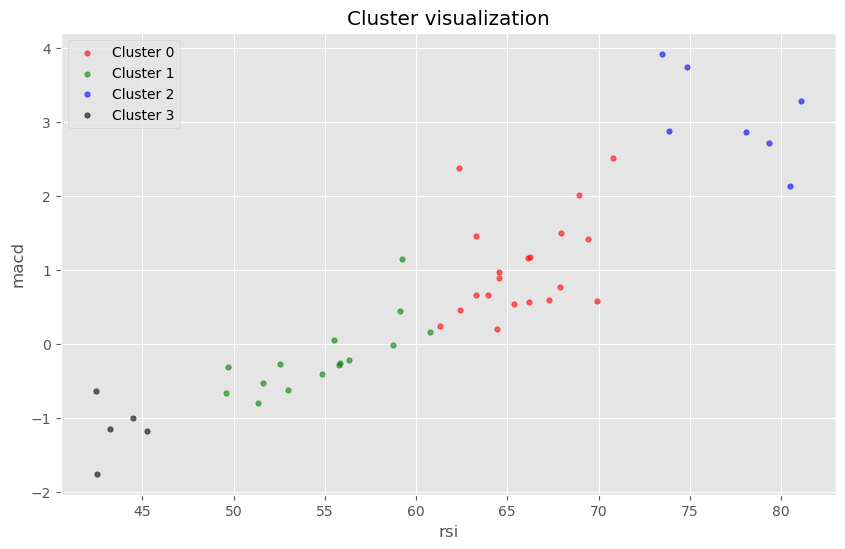

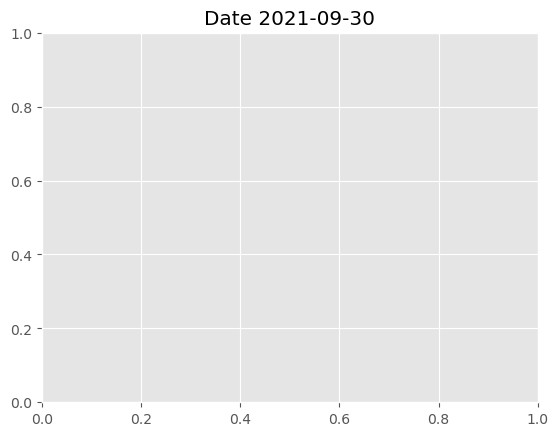

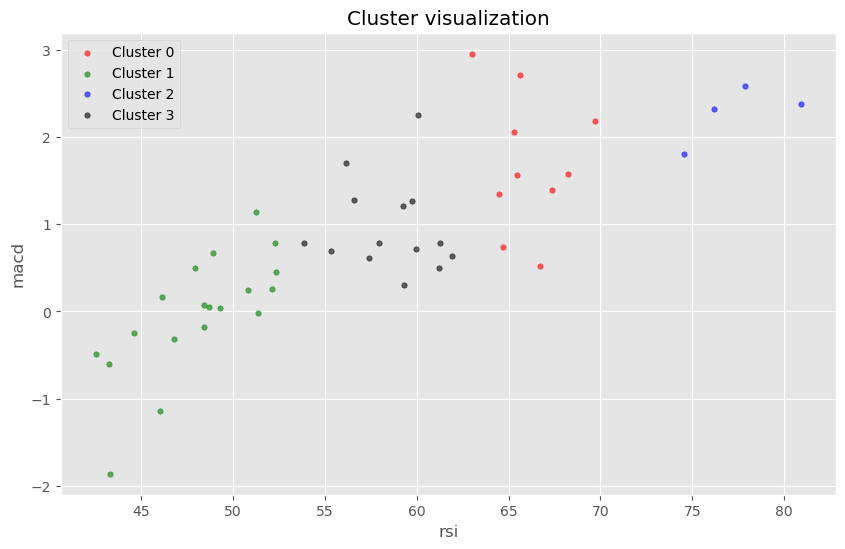

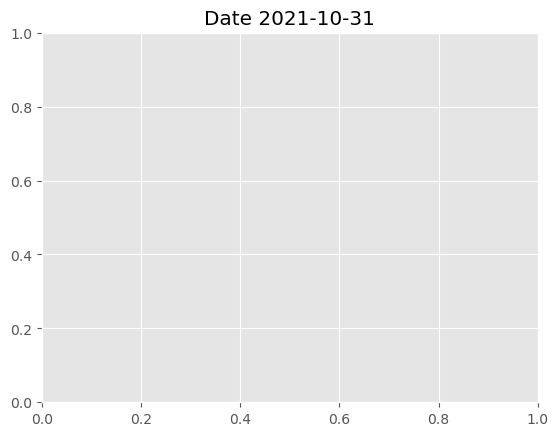

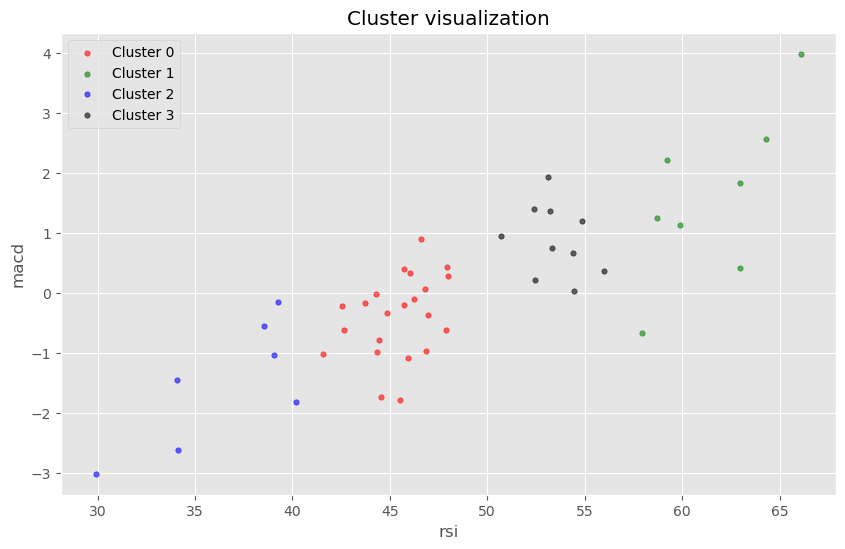

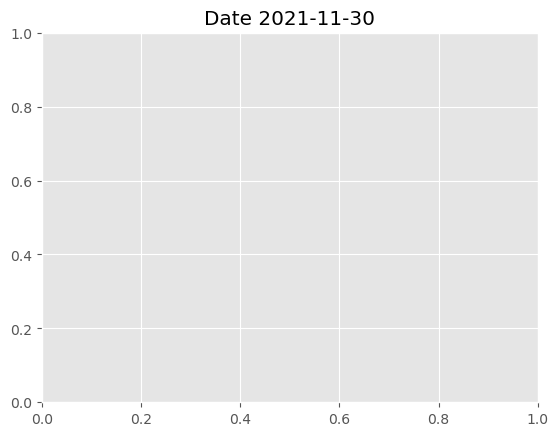

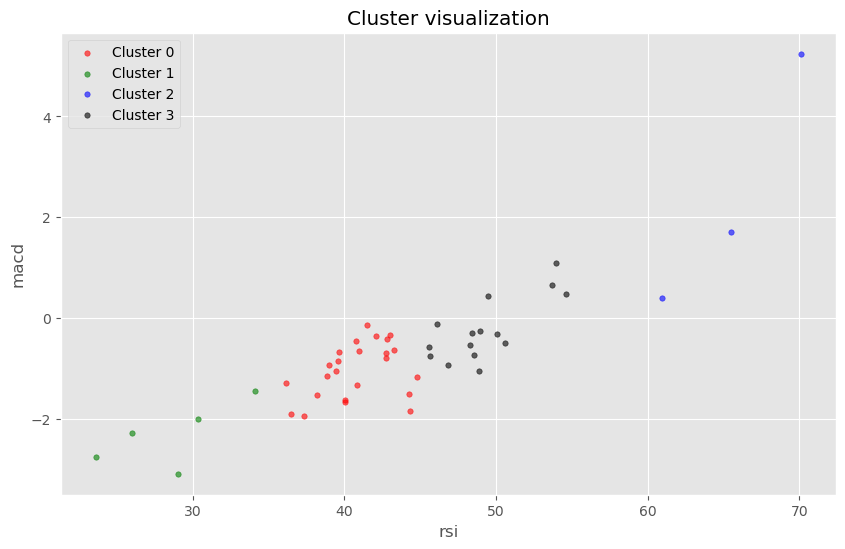

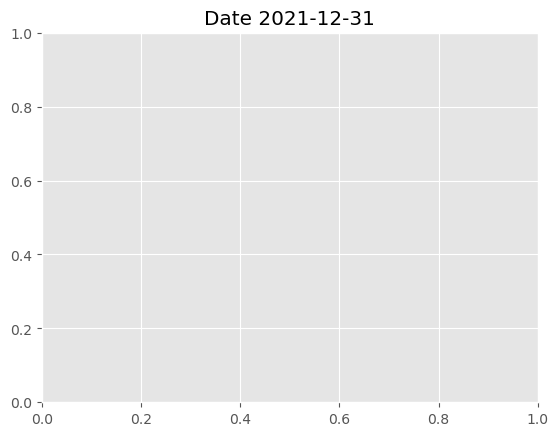

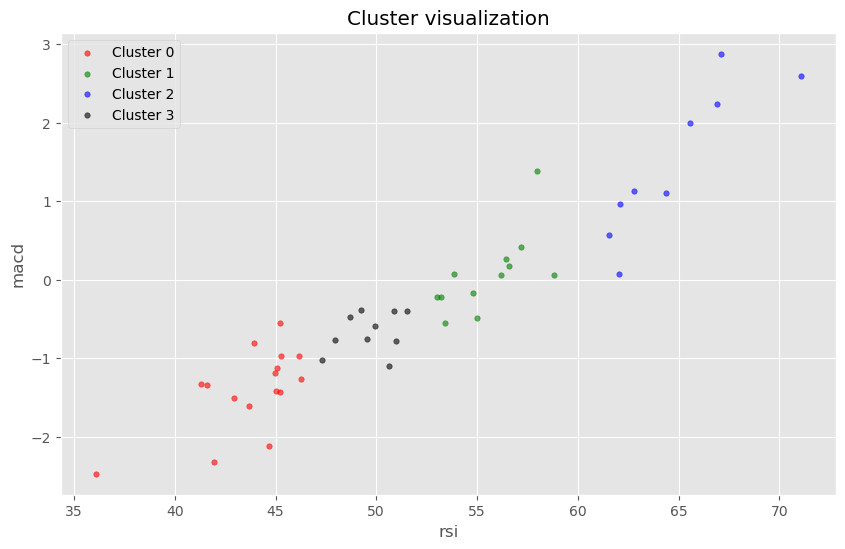

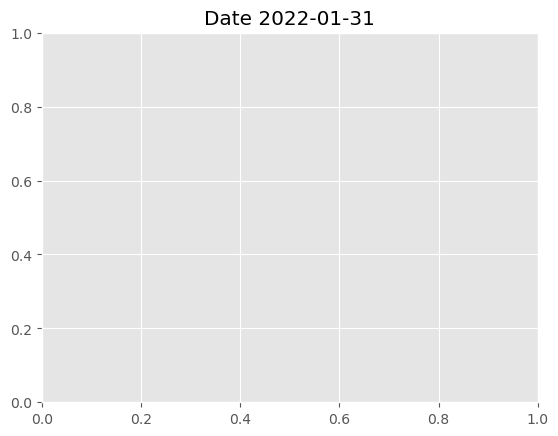

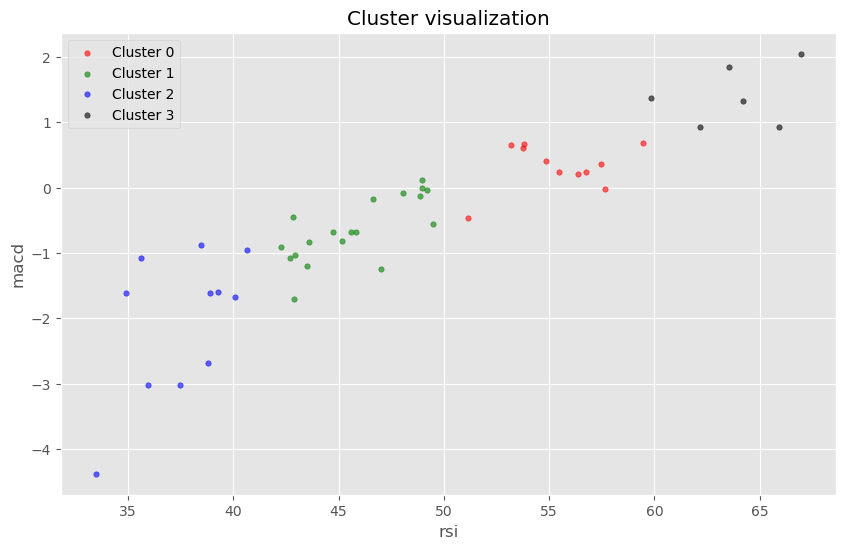

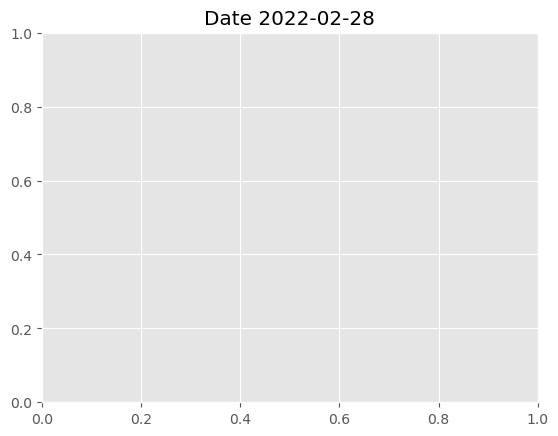

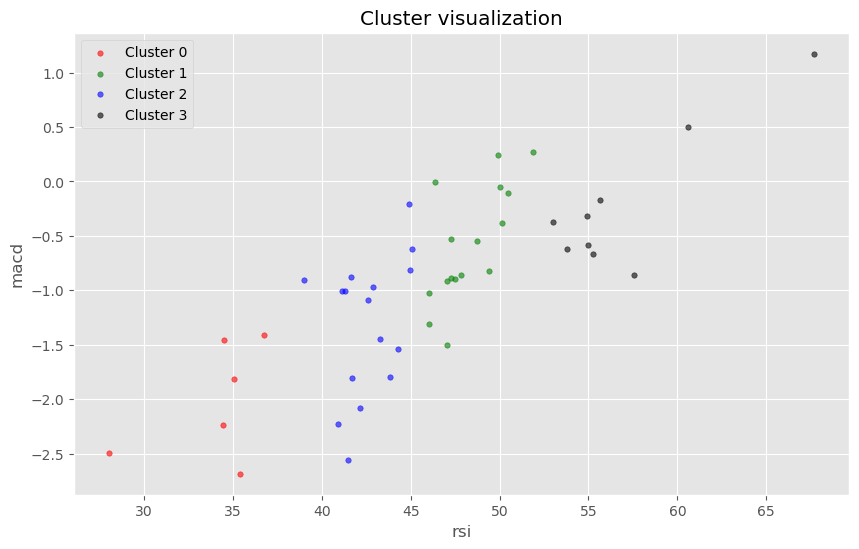

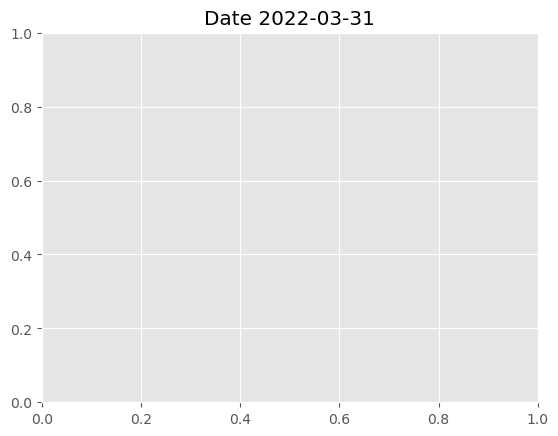

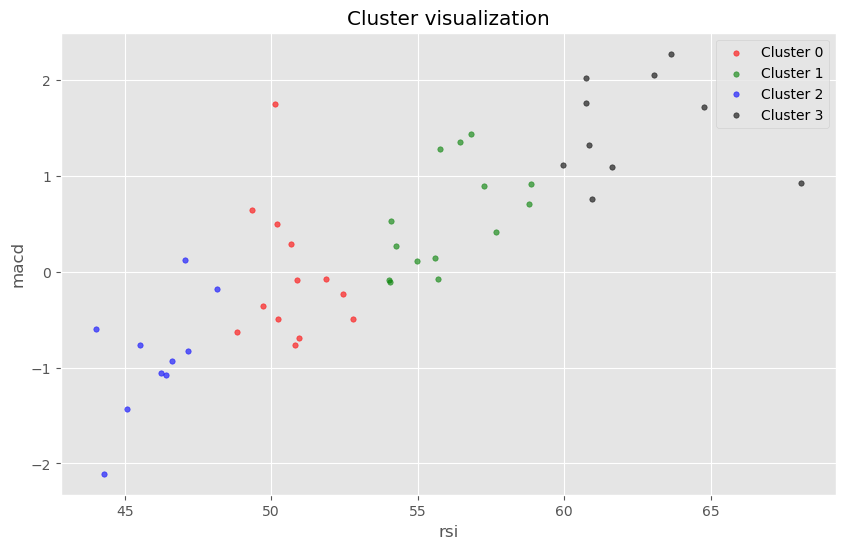

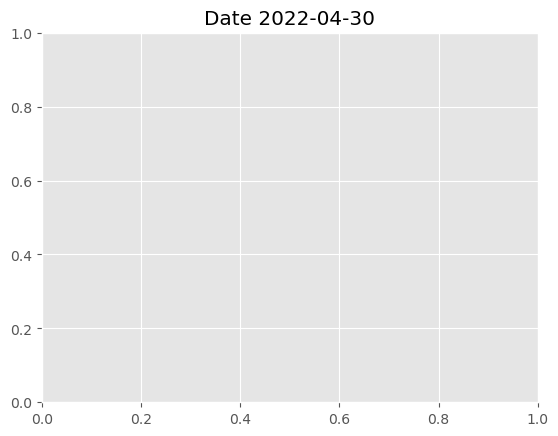

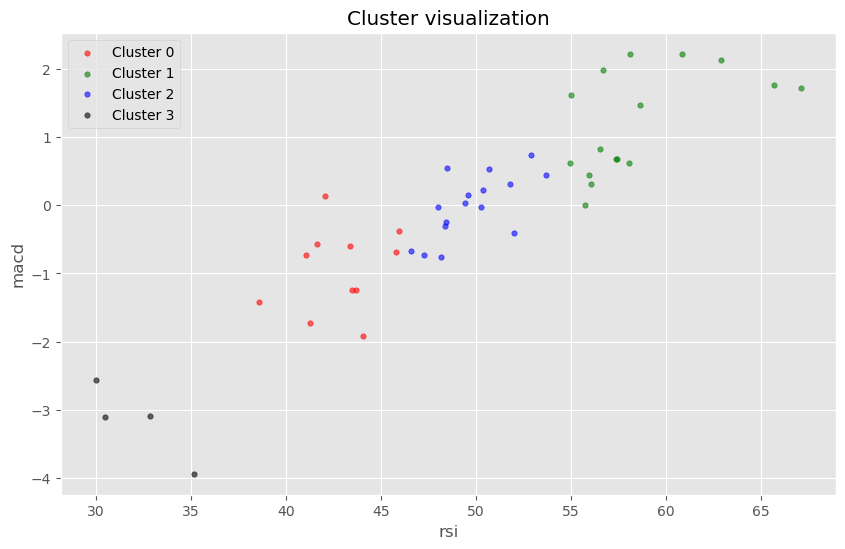

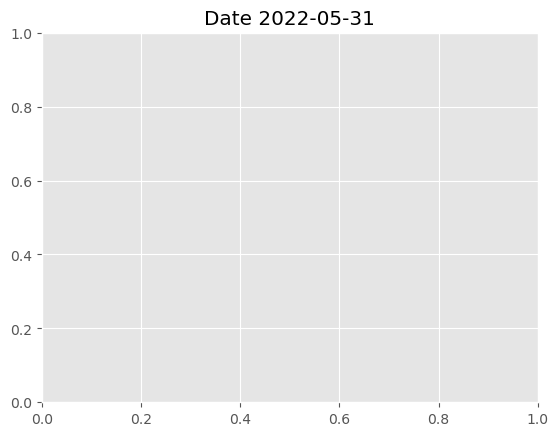

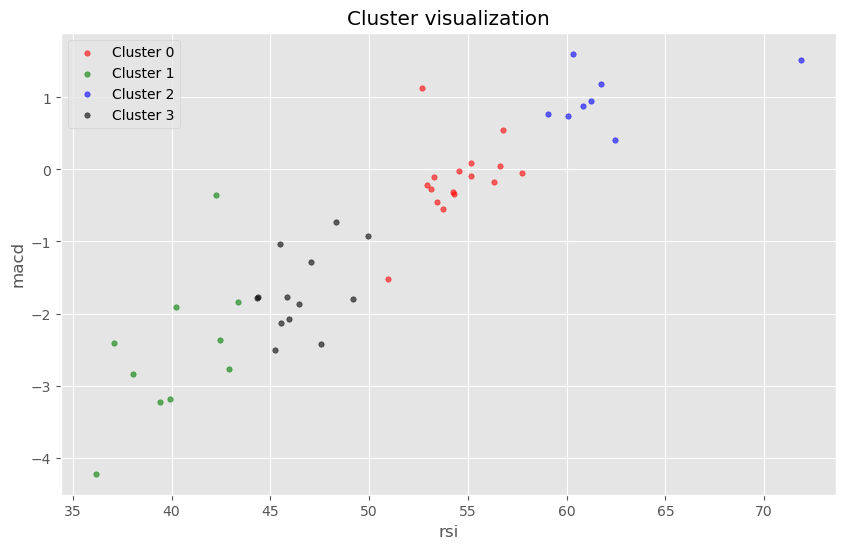

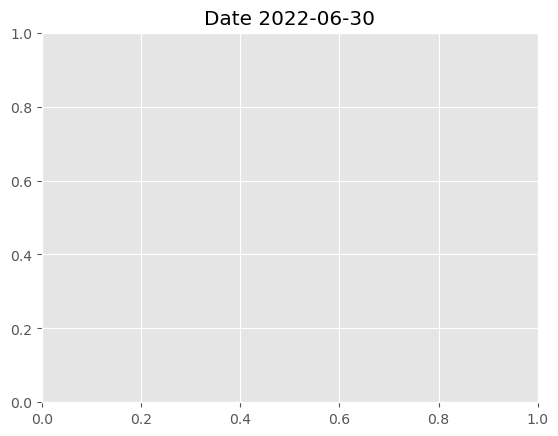

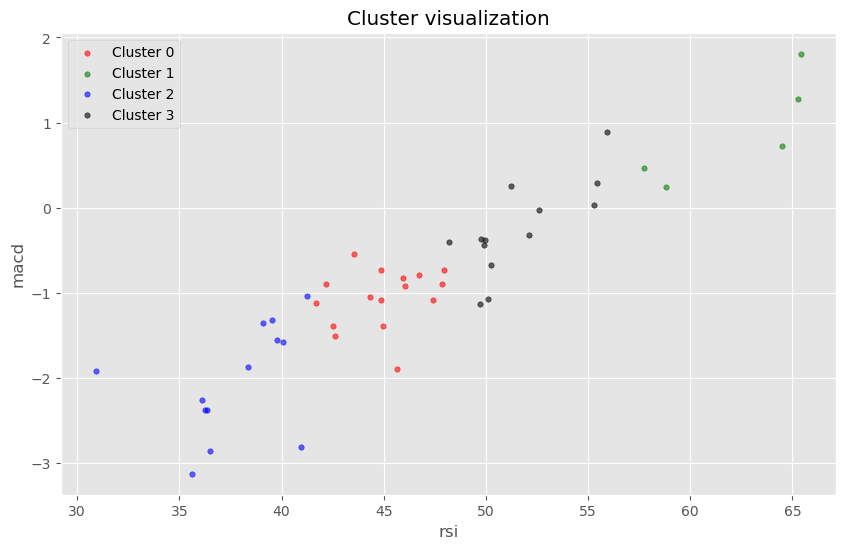

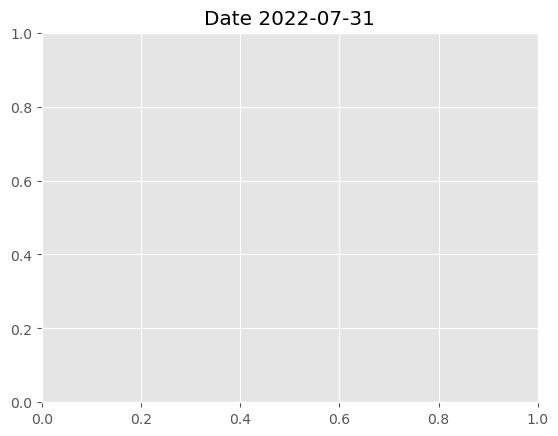

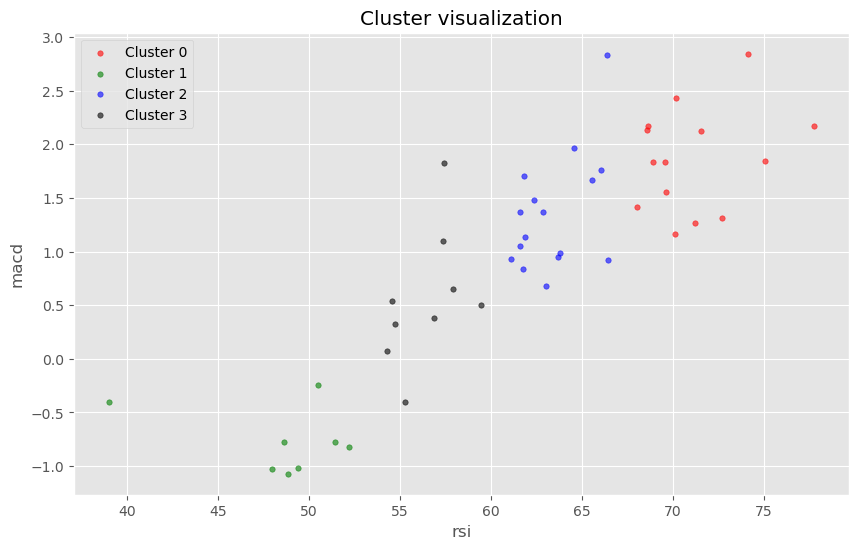

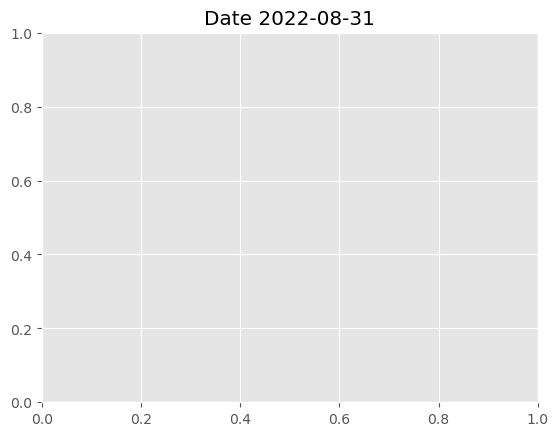

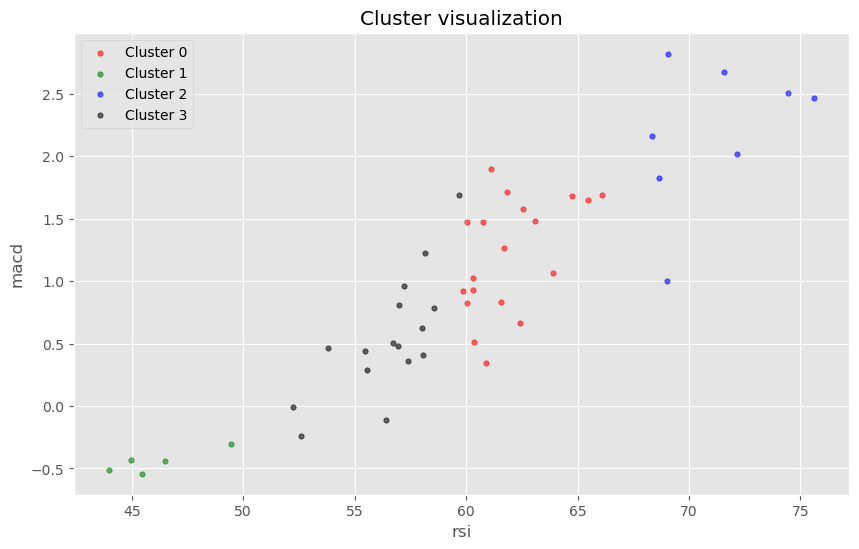

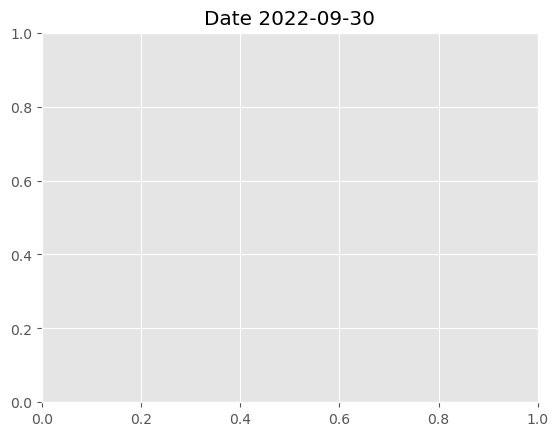

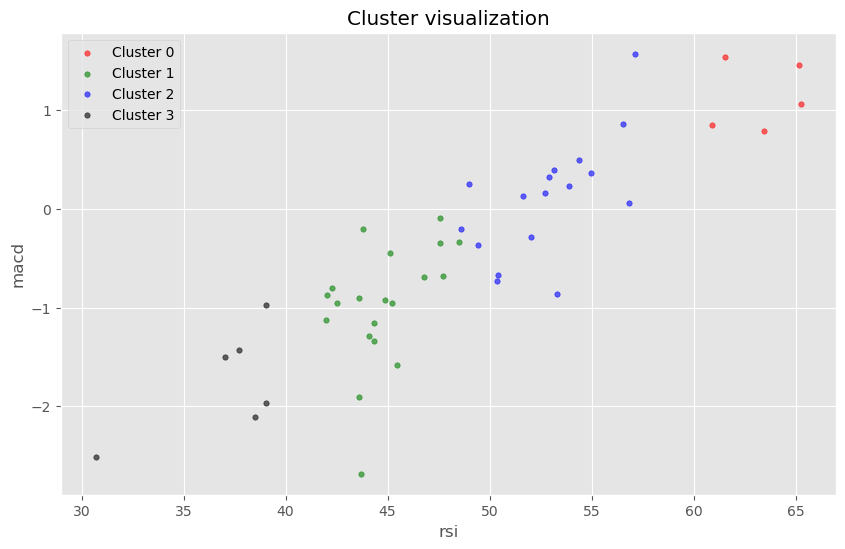

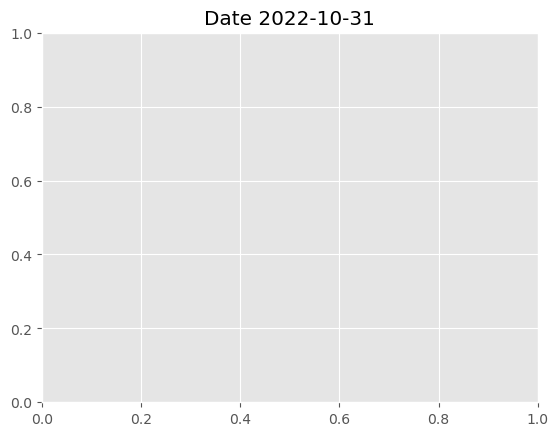

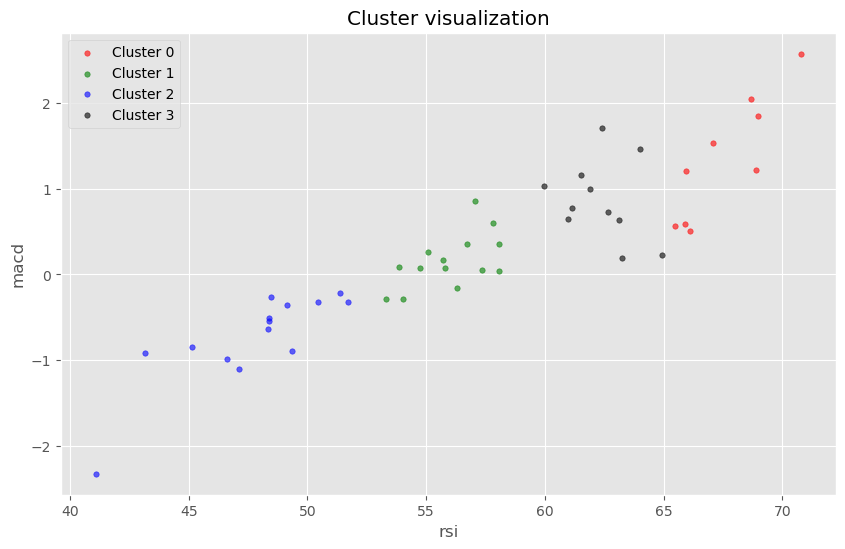

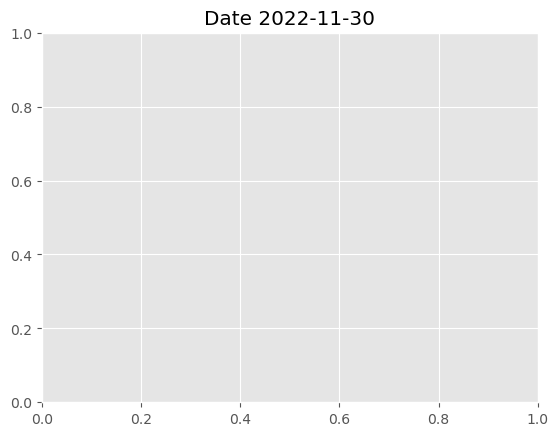

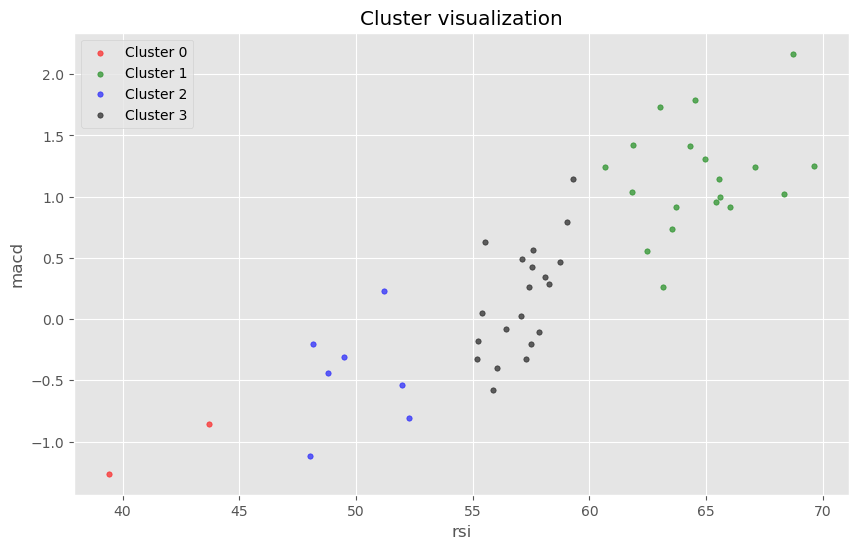

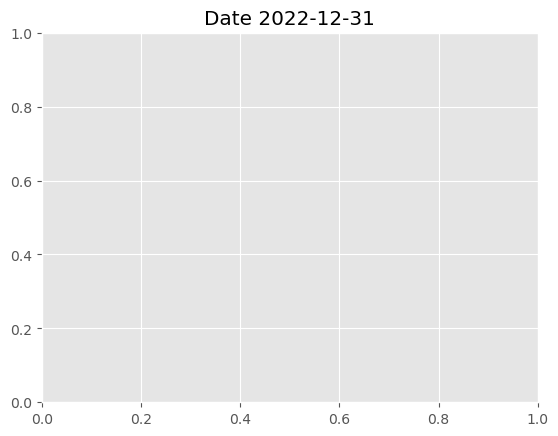

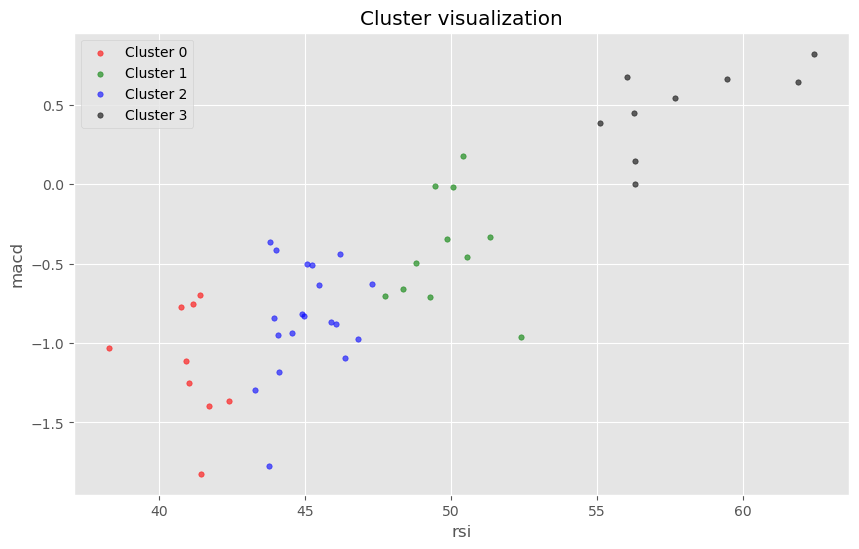

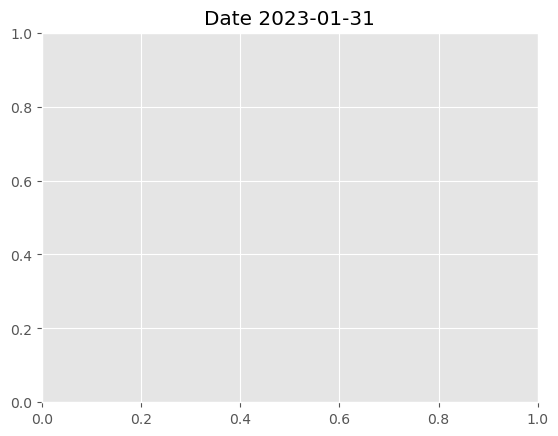

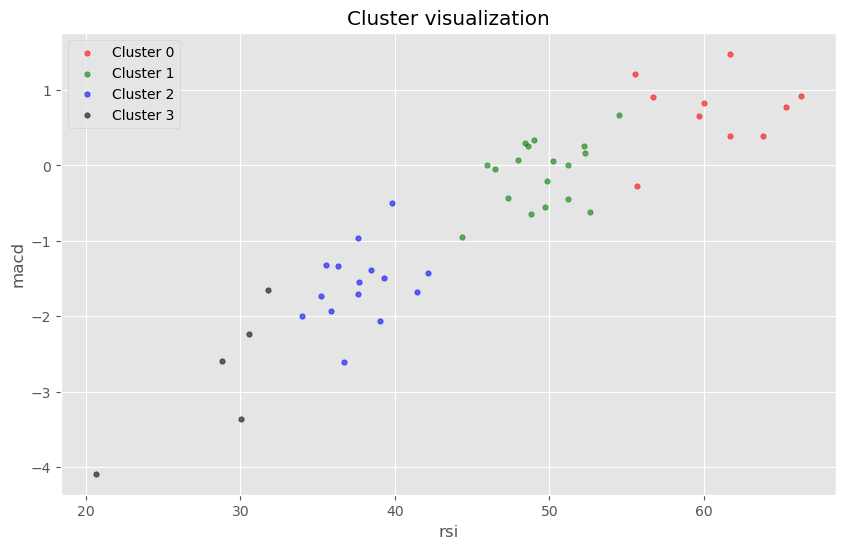

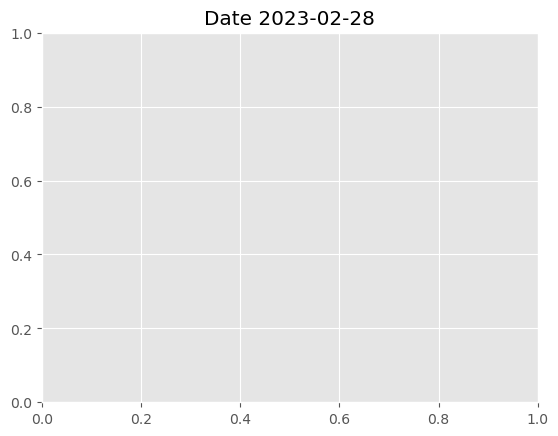

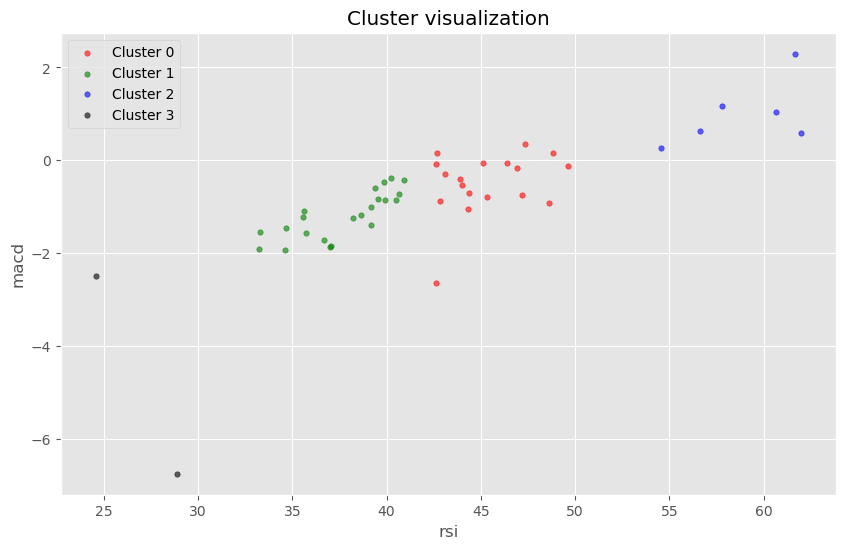

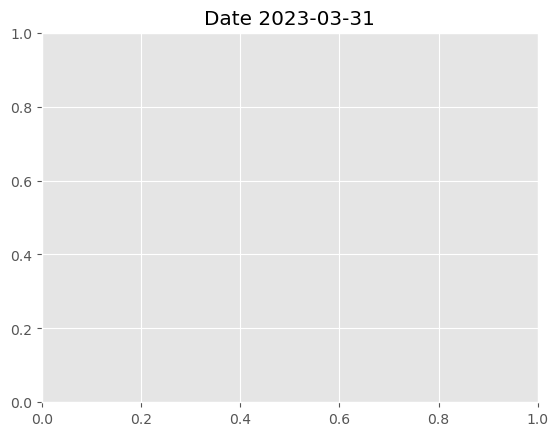

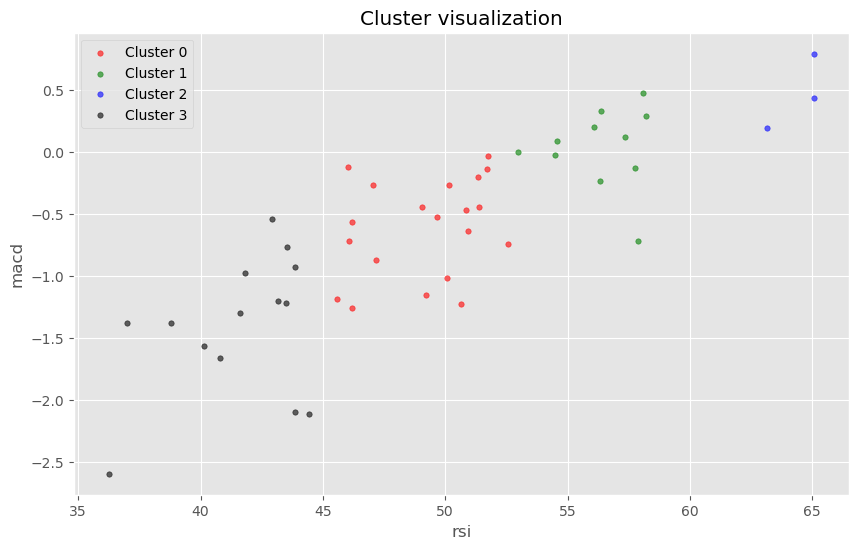

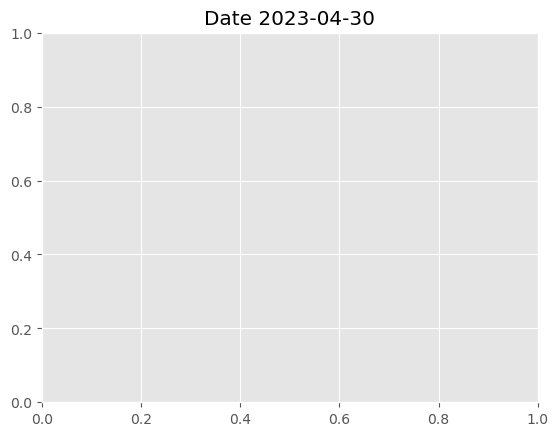

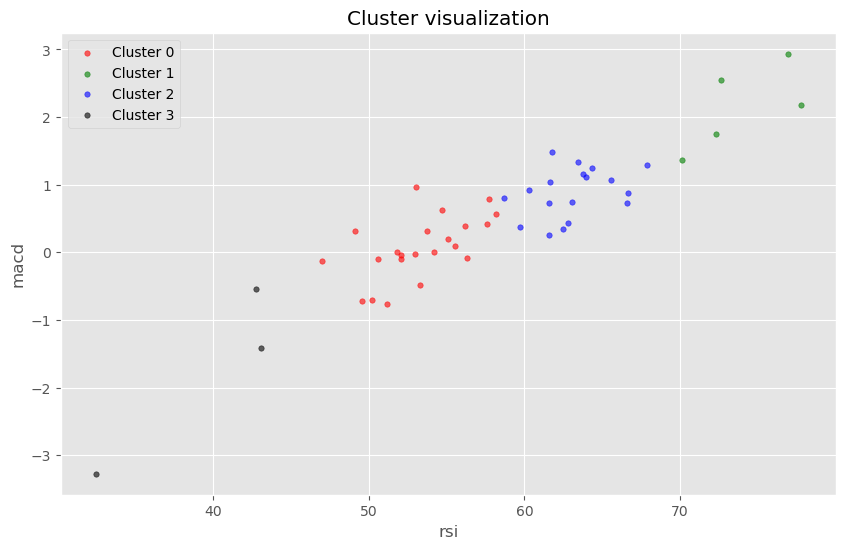

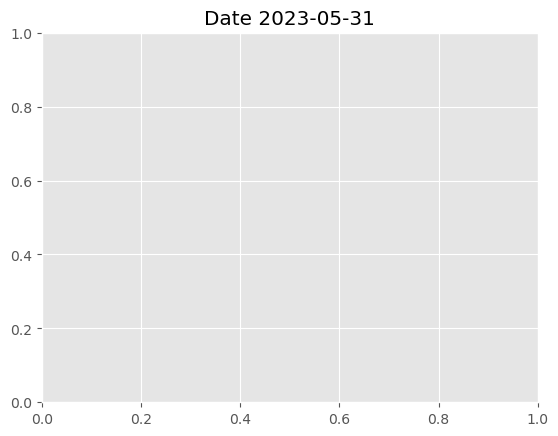

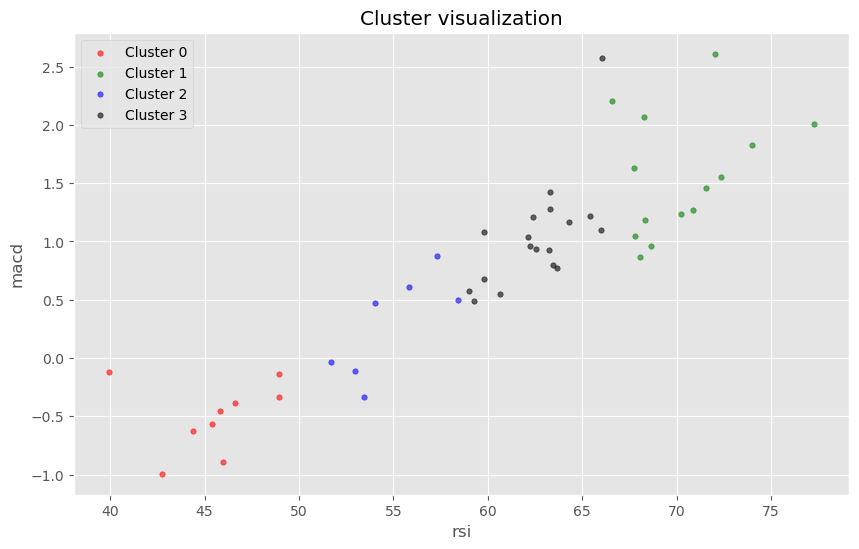

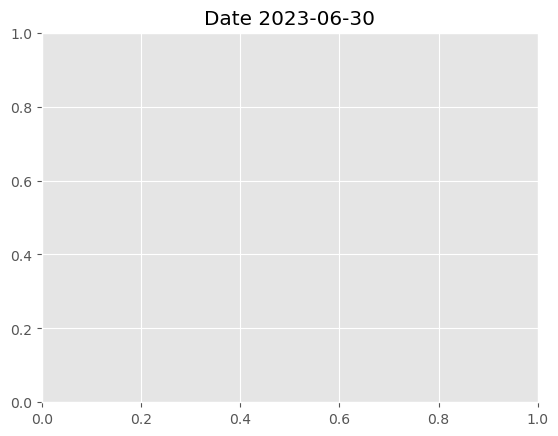

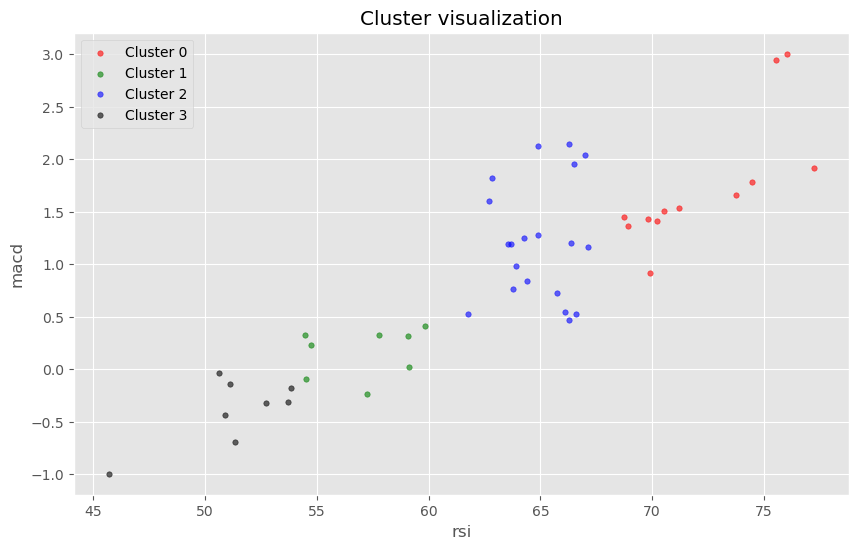

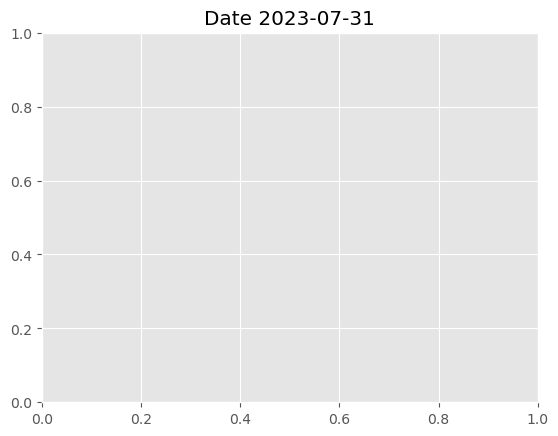

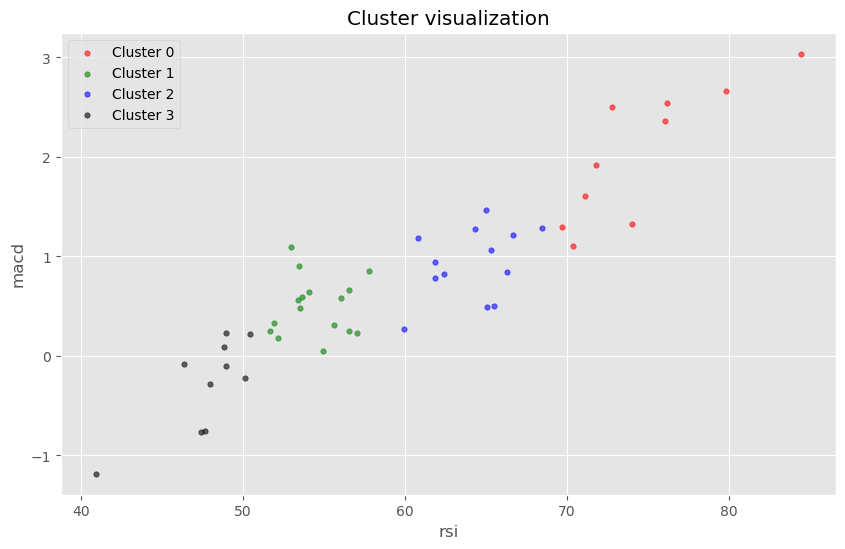

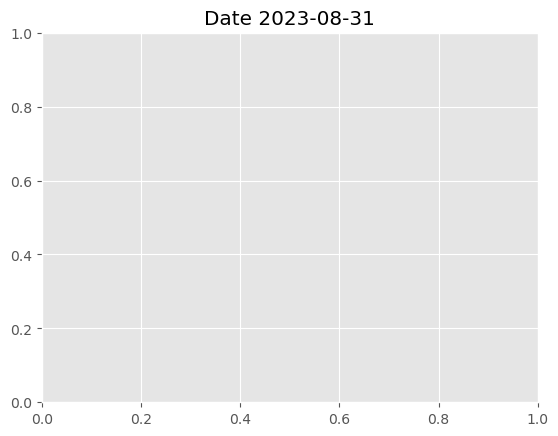

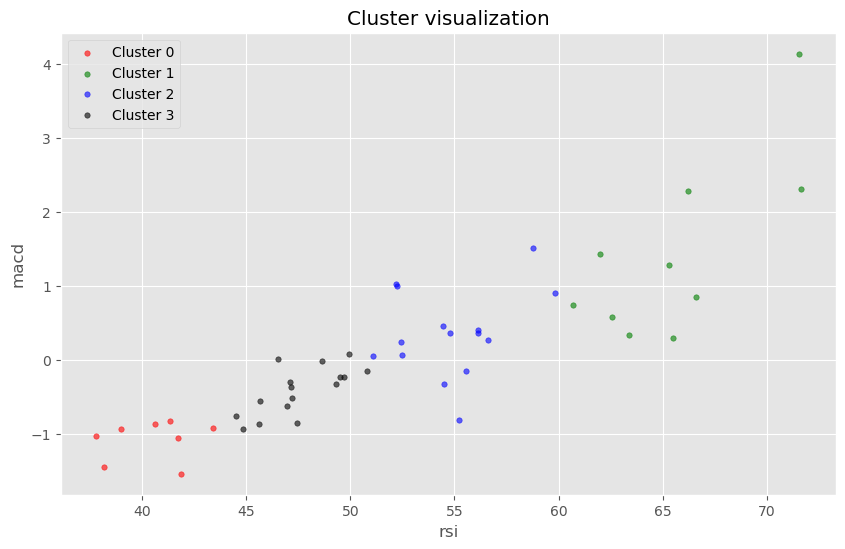

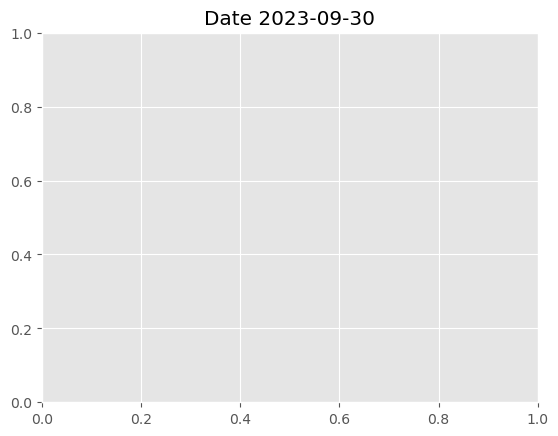

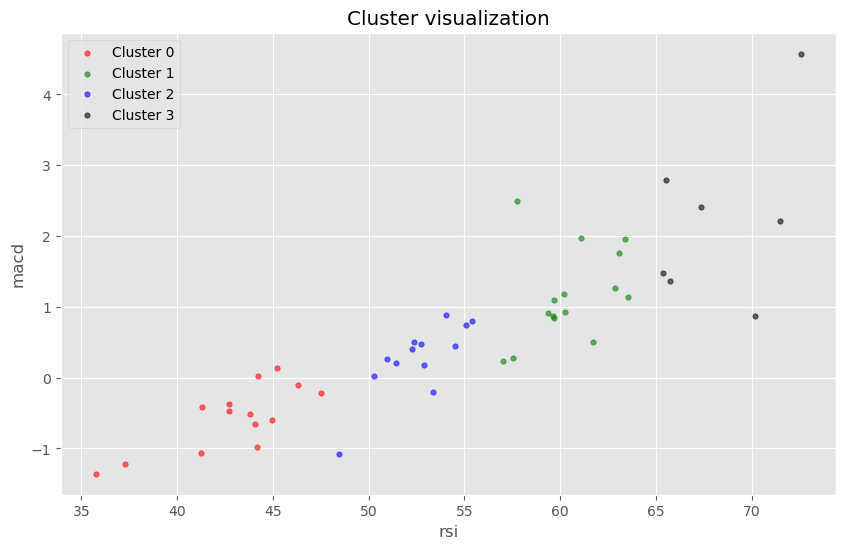

In [42]:
x_feature = 'rsi'
y_feature = 'macd'

plt.style.use('ggplot')

for date in data.index.get_level_values('date').unique():
    g = data.xs(date, level='date')

    plt.title(f'Date {date.date()}')        # nicer formatting
    plot_clusters(g, x_feature, y_feature)  # pass the features


### Apply pre-defined centroids.

In [43]:
target_rsi_values = [30, 45, 55, 70]
initial_centroids = np.zeros((len(target_rsi_values), 18))
initial_centroids[:, 6] = target_rsi_values

## 7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization

* First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

* Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.


In [44]:
filtered_df = data[data['cluster']==3].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:
    
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
    
fixed_dates

{'2017-11-01': ['ASIANPAINT.NS',
  'BAJFINANCE.NS',
  'HDFCBANK.NS',
  'HINDUNILVR.NS',
  'INFY.NS',
  'JSWSTEEL.NS',
  'KOTAKBANK.NS',
  'M&M.NS',
  'NESTLEIND.NS',
  'POWERGRID.NS',
  'TATAMOTORS.NS',
  'TRENT.NS',
  'WIPRO.NS'],
 '2017-12-01': ['APOLLOHOSP.NS',
  'BAJAJ-AUTO.NS',
  'BEL.NS',
  'BHARTIARTL.NS',
  'HDFCBANK.NS',
  'HINDUNILVR.NS',
  'INFY.NS',
  'M&M.NS',
  'NESTLEIND.NS',
  'NTPC.NS',
  'RELIANCE.NS',
  'SBIN.NS',
  'TECHM.NS'],
 '2018-01-01': ['APOLLOHOSP.NS',
  'AXISBANK.NS',
  'BAJAJ-AUTO.NS',
  'BHARTIARTL.NS',
  'DRREDDY.NS',
  'HINDALCO.NS',
  'JSWSTEEL.NS',
  'LT.NS',
  'M&M.NS',
  'NESTLEIND.NS',
  'SUNPHARMA.NS',
  'TATAMOTORS.NS',
  'TATASTEEL.NS',
  'TCS.NS',
  'TRENT.NS'],
 '2018-02-01': ['ASIANPAINT.NS',
  'BAJAJFINSV.NS',
  'BEL.NS',
  'BHARTIARTL.NS',
  'DRREDDY.NS',
  'EICHERMOT.NS',
  'NESTLEIND.NS',
  'NTPC.NS',
  'POWERGRID.NS',
  'TATAMOTORS.NS'],
 '2018-03-01': ['ADANIENT.NS',
  'APOLLOHOSP.NS',
  'BAJAJFINSV.NS',
  'GRASIM.NS',
  'HCLTECH.NS',
 

### Define portfolio optimization function

* We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.

* To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

* Apply signle stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).

In [45]:
def optimize_weights(prices, lower_bound=0):
    
    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)
    
    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)
    
    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')
    
    weights = ef.max_sharpe()
    
    return ef.clean_weights()

* Download Fresh Daily Prices Data only for short listed stocks.

In [ ]:
stocks = data.index.get_level_values('ticker').unique().tolist()

start_date = data.index.get_level_values('date').min() - pd.DateOffset(months=12)
end_date   = data.index.get_level_values('date').max()

raw_prices = yf.download(
    tickers=stocks,
    start=start_date,
    end=end_date
)

daily_close = raw_prices['Close'].dropna(axis=1, how='all')

daily_close


[*********************100%***********************]  49 of 49 completed


Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATAMOTORS.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2016-11-01,35.629055,290.396698,1299.407593,1000.446777,468.629578,2221.400879,344.562012,103.048882,34.062683,272.067047,...,679.432495,126.003128,521.215454,31.413450,961.252014,320.529877,360.612183,203.815491,3827.583252,80.516937
2016-11-02,34.561504,285.400513,1264.003784,987.484924,469.614471,2216.054932,335.960144,99.070900,33.336735,265.339264,...,661.190796,122.684860,504.221466,31.086300,942.456421,317.757385,365.353271,197.278839,3749.958740,80.018890
2016-11-03,34.428066,274.266205,1242.732300,963.697937,468.678802,2224.742188,333.489655,100.139473,33.426350,264.782166,...,651.560730,119.412048,501.176331,30.330481,948.755493,316.426636,364.966248,198.605820,3760.112549,78.218948
2016-11-04,33.307156,273.790344,1248.705811,969.180176,471.485840,2212.517090,318.442749,96.477188,33.285507,262.853882,...,603.271240,115.321053,503.239136,30.315441,953.296204,317.942261,357.080536,192.462341,3709.966797,79.075226
2016-11-07,33.680790,279.309967,1243.800781,963.883789,478.084900,2220.221680,312.938873,96.210045,33.340561,261.911133,...,606.419495,116.366524,497.394379,31.029896,931.412109,328.884094,358.483551,191.970856,3761.893555,78.638359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-25,2479.900635,818.142273,5070.968750,3244.995850,1017.294861,4842.373047,1575.637817,773.307251,134.176239,897.848755,...,1103.837646,887.853149,609.651550,122.037880,3383.288330,1215.792603,3263.418457,2153.705322,8106.437988,198.675995
2023-09-26,2455.771729,813.881348,5027.840820,3215.262939,1012.502625,4904.045410,1565.948608,778.330933,135.207596,900.117004,...,1105.605225,882.529602,610.735413,123.474739,3391.375244,1199.746826,3242.201904,2147.614502,8128.861816,198.100266
2023-09-27,2481.099609,823.146423,5079.226074,3224.051025,1023.534668,4868.976562,1564.000854,775.057617,134.176239,907.562866,...,1119.451538,876.269470,611.080322,122.756310,3394.780518,1205.687988,3194.452393,2110.572510,8162.250977,199.419647


* Calculate daily returns for each stock which could land up in our portfolio.

* Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

* If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

* Calculated each day portfolio return.

In [49]:
# 1. Daily log returns from close prices
returns_dataframe = np.log(daily_close).diff()   # index: Date, columns: tickers

portfolio_returns = []  # list of Series (each is a period of daily returns)

for start_str, cols in fixed_dates.items():
    try:
        start_date = pd.to_datetime(start_str)
        end_date = start_date + pd.offsets.MonthEnd(0)      # hold until month-end

        # 12-month lookback window for optimization
        optimization_start_date = start_date - pd.DateOffset(months=12)
        optimization_end_date = start_date - pd.DateOffset(days=1)

        # price history for this basket in the lookback window
        optimization_df = (
            daily_close
            .loc[optimization_start_date:optimization_end_date, cols]
            .dropna(axis=1, how='any')  # keep only tickers with full history in lookback
        )

        if optimization_df.shape[1] == 0:
            print(f"No valid data to optimize for {start_str}, skipping")
            continue

        # lower bound: half of equal-weight
        lb = round(1 / (2 * optimization_df.shape[1]), 3)

        # try to get optimized weights
        success = False
        try:
            weight_dict = optimize_weights(prices=optimization_df, lower_bound=lb)
            # dict -> Series, aligned to current tickers
            weights = (
                pd.Series(weight_dict)
                .reindex(optimization_df.columns)
                .fillna(0.0)
            )
            success = True
        except Exception as e:
            print(f"Max Sharpe optimization failed for {start_str}: {e}")
            print("Continuing with equal weights")

        # fallback to equal weights if optimization failed
        if not success:
            n = optimization_df.shape[1]
            weights = pd.Series(1 / n, index=optimization_df.columns)

        # forward period daily returns (from start_date to end_of_month)
        period_rets = (
            returns_dataframe
            .loc[start_date:end_date, weights.index]   # align tickers
            .dropna(how='all')
        )

        if period_rets.empty:
            print(f"No forward returns for {start_str}, skipping")
            continue

        # daily portfolio return = weighted sum over tickers
        strat_ret = (period_rets * weights).sum(axis=1)
        strat_ret.name = 'Strategy Return'

        portfolio_returns.append(strat_ret)

    except Exception as e:
        print(f"Error at {start_str}: {e}")

# 3. Combine all holding periods into one series and remove duplicate dates
portfolio_df = pd.concat(portfolio_returns).to_frame()
portfolio_df = portfolio_df[~portfolio_df.index.duplicated(keep='first')]

portfolio_df


Max Sharpe optimization failed for 2017-11-01: name 'expected_returns' is not defined
Continuing with equal weights
Max Sharpe optimization failed for 2017-12-01: name 'expected_returns' is not defined
Continuing with equal weights
Max Sharpe optimization failed for 2018-01-01: name 'expected_returns' is not defined
Continuing with equal weights
Max Sharpe optimization failed for 2018-02-01: name 'expected_returns' is not defined
Continuing with equal weights
Max Sharpe optimization failed for 2018-03-01: name 'expected_returns' is not defined
Continuing with equal weights
Max Sharpe optimization failed for 2018-04-01: name 'expected_returns' is not defined
Continuing with equal weights
Max Sharpe optimization failed for 2018-05-01: name 'expected_returns' is not defined
Continuing with equal weights
Max Sharpe optimization failed for 2018-06-01: name 'expected_returns' is not defined
Continuing with equal weights
Max Sharpe optimization failed for 2018-07-01: name 'expected_returns' i

,Strategy Return
Date,
2017-11-01,0.007256
2017-11-02,-0.001162
2017-11-03,0.003217
2017-11-06,0.007016
2017-11-07,-0.004752
...,...
2023-09-25,0.006893
2023-09-26,0.001900
2023-09-27,-0.000414


## 8. Visualize Portfolio returns and compare to SP500 returns.

In [52]:
nifty.columns

MultiIndex([( 'Close', '^NSEI'),
            (  'High', '^NSEI'),
            (   'Low', '^NSEI'),
            (  'Open', '^NSEI'),
            ('Volume', '^NSEI')],
           names=['Price', 'Ticker'])

In [53]:
nifty = yf.download(
    tickers='^NSEI',
    start='2015-01-01',
    end=dt.date.today()
)

# Use the 'Close' prices (single column: '^NSEI')
nifty_ret = (
    np.log(nifty['Close'])      # select level-0 'Close' → col '^NSEI'
      .diff()
      .dropna()
      .rename(columns={'^NSEI': 'NIFTY50 Buy&Hold'})
)

portfolio_df = portfolio_df.merge(
    nifty_ret,
    left_index=True,
    right_index=True
)

portfolio_df


[*********************100%***********************]  1 of 1 completed


,Strategy Return,NIFTY50 Buy&Hold
Date,,
2017-11-01,0.007256,0.010127
2017-11-02,-0.001162,-0.001601
2017-11-03,0.003217,0.002750
2017-11-06,0.007016,-0.000067
2017-11-07,-0.004752,-0.009773
...,...,...
2023-09-25,0.006893,0.000015
2023-09-26,0.001900,-0.000501
2023-09-27,-0.000414,0.002628


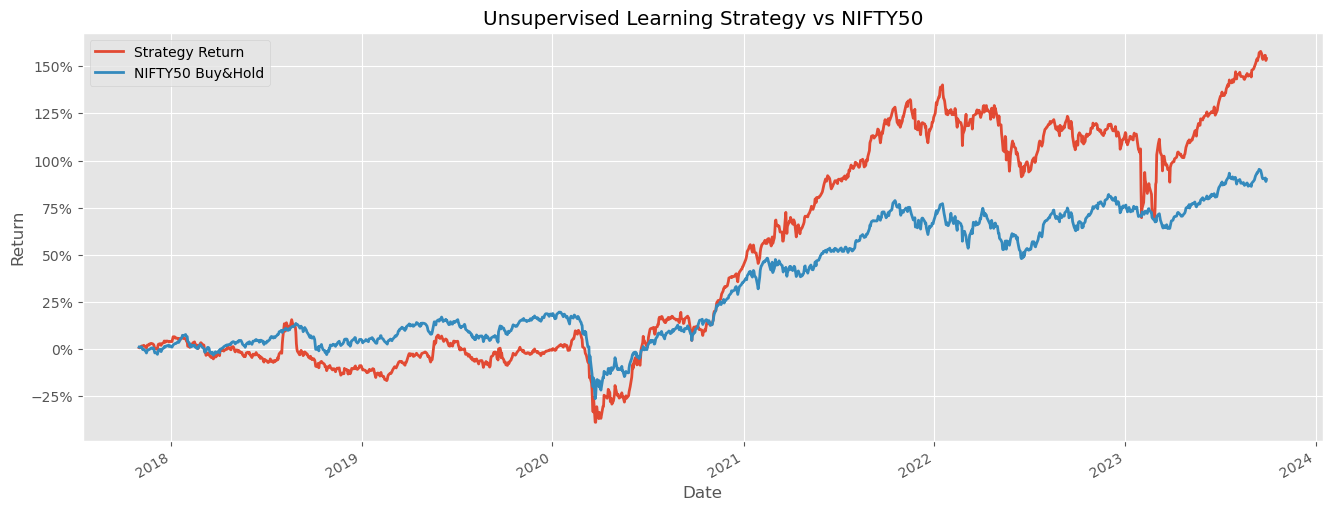

In [54]:
import matplotlib.ticker as mtick
plt.style.use('ggplot')

# 1. portfolio_df contains log returns already → just cumulative sum + exp
portfolio_cumulative_return = np.exp(portfolio_df.cumsum()) - 1

# 2. Plot until your strategy’s last date
portfolio_cumulative_return[:'2023-09-29'].plot(
    figsize=(16,6),
    linewidth=2
)

plt.title('Unsupervised Learning Strategy vs NIFTY50')
plt.ylabel('Return')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.grid(True)
plt.show()

# Twitter Sentiment Investing Strategy

## 1. Load Twitter Sentiment Data

* Load the twitter sentiment dataset, set the index, calculat engagement ratio and filter out stocks with no significant twitter activity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import os
plt.style.use('ggplot')

data_folder = 'C:/Users/user/Desktop/Python Scripts'

sentiment_df = pd.read_csv(os.path.join(data_folder, 'sentiment_data.csv'))

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

sentiment_df = sentiment_df.set_index(['date', 'symbol'])

sentiment_df['engagement_ratio'] = sentiment_df['twitterComments']/sentiment_df['twitterLikes']

sentiment_df = sentiment_df[(sentiment_df['twitterLikes']>20)&(sentiment_df['twitterComments']>10)]

sentiment_df

## 2. Aggregate Monthly and calculate average sentiment for the month

* Aggregate on a monthly level and calculate average monthly metric, for the one we choose.

In [ ]:
aggragated_df = (sentiment_df.reset_index('symbol').groupby([pd.Grouper(freq='M'), 'symbol'])
                    [['engagement_ratio']].mean())

aggragated_df['rank'] = (aggragated_df.groupby(level=0)['engagement_ratio']
                         .transform(lambda x: x.rank(ascending=False)))

aggragated_df

## 3. Select Top 5 Stocks based on their cross-sectional ranking for each month

* Select top 5 stocks by rank for each month and fix the date to start at beginning of next month.

In [ ]:
filtered_df = aggragated_df[aggragated_df['rank']<6].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'symbol'])

filtered_df.head(20)

## 4. Extract the stocks to form portfolios with at the start of each new month

* Create a dictionary containing start of month and corresponded selected stocks.

In [ ]:
dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:
    
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
    
fixed_dates

## 5. Download fresh stock prices for only selected/shortlisted stocks

In [ ]:
stocks_list = sentiment_df.index.get_level_values('symbol').unique().tolist()

prices_df = yf.download(tickers=stocks_list,
                        start='2021-01-01',
                        end='2023-03-01')

## 6. Calculate Portfolio Returns with monthly rebalancing


In [ ]:
returns_df = np.log(prices_df['Adj Close']).diff().dropna()

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():
    
    end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd()).strftime('%Y-%m-%d')
    
    cols = fixed_dates[start_date]
    
    temp_df = returns_df[start_date:end_date][cols].mean(axis=1).to_frame('portfolio_return')
    
    portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)
    
portfolio_df

## 7. Download NASDAQ/QQQ prices and calculate returns to compare to our strategy

In [ ]:
qqq_df = yf.download(tickers='QQQ',
                     start='2021-01-01',
                     end='2023-03-01')

qqq_ret = np.log(qqq_df['Adj Close']).diff().to_frame('nasdaq_return')

portfolio_df = portfolio_df.merge(qqq_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df

In [ ]:
portfolios_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum()).sub(1)

portfolios_cumulative_return.plot(figsize=(16,6))

plt.title('Twitter Engagement Ratio Strategy Return Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()

# Intraday Strategy Using GARCH Model


* Using simulated daily data and intraday 5-min data.
* Load Daily and 5-minute data.
* Define function to fit GARCH model on the daily data and predict 1-day ahead volatility in a rolling window.
* Calculate prediction premium and form a daily signal from it.
* Merge with intraday data and calculate intraday indicators to form the intraday signal.
* Generate the position entry and hold until the end of the day.
* Calculate final strategy returns.

## 1. Load Simulated Daily and Simulated 5-minute data.

* We are loading both datasets, set the indexes and calculate daily log returns.

In [ ]:
import matplotlib.pyplot as plt
from arch import arch_model
import pandas_ta
import pandas as pd
import numpy as np
import os

data_folder = 'C:/Users/user/Desktop/Python Scripts'

daily_df = pd.read_csv(os.path.join(data_folder, 'simulated_daily_data.csv'))

daily_df = daily_df.drop('Unnamed: 7', axis=1)

daily_df['Date'] = pd.to_datetime(daily_df['Date'])

daily_df = daily_df.set_index('Date')


intraday_5min_df = pd.read_csv(os.path.join(data_folder, 'simulated_5min_data.csv'))

intraday_5min_df = intraday_5min_df.drop('Unnamed: 6', axis=1)

intraday_5min_df['datetime'] = pd.to_datetime(intraday_5min_df['datetime'])

intraday_5min_df = intraday_5min_df.set_index('datetime')

intraday_5min_df['date'] = pd.to_datetime(intraday_5min_df.index.date)

intraday_5min_df

## 2. Define function to fit GARCH model and predict 1-day ahead volatility in a rolling window.

* We are first calculating the 6-month rolling variance and then we are creating a function in a 6-month rolling window to fit a garch model and predict the next day variance.

In [ ]:
daily_df['log_ret'] = np.log(daily_df['Adj Close']).diff()

daily_df['variance'] = daily_df['log_ret'].rolling(180).var()

daily_df = daily_df['2020':]

def predict_volatility(x):
    
    best_model = arch_model(y=x,
                            p=1,
                            q=3).fit(update_freq=5,
                                     disp='off')
    
    variance_forecast = best_model.forecast(horizon=1).variance.iloc[-1,0]

    print(x.index[-1])
    
    return variance_forecast

daily_df['predictions'] = daily_df['log_ret'].rolling(180).apply(lambda x: predict_volatility(x))

daily_df = daily_df.dropna()

daily_df

## 3. Calculate prediction premium and form a daily signal from it.

* We are calculating the prediction premium. And calculate its 6-month rolling standard deviation.

* From this we are creating our daily signal.

In [ ]:
daily_df['prediction_premium'] = (daily_df['predictions']-daily_df['variance'])/daily_df['variance']

daily_df['premium_std'] = daily_df['prediction_premium'].rolling(180).std()

daily_df['signal_daily'] = daily_df.apply(lambda x: 1 if (x['prediction_premium']>x['premium_std'])
                                         else (-1 if (x['prediction_premium']<x['premium_std']*-1) else np.nan),
                                         axis=1)

daily_df['signal_daily'] = daily_df['signal_daily'].shift()

daily_df

In [ ]:
plt.style.use('ggplot')

daily_df['signal_daily'].plot(kind='hist')

plt.show()

## 4. Merge with intraday data and calculate intraday indicators to form the intraday signal.

* Calculate all intraday indicators and intraday signal.

In [ ]:
final_df = intraday_5min_df.reset_index()\
                            .merge(daily_df[['signal_daily']].reset_index(),
                                   left_on='date',
                                   right_on='Date')\
                            .drop(['date','Date'], axis=1)\
                            .set_index('datetime')

final_df['rsi'] = pandas_ta.rsi(close=final_df['close'],
                                length=20)

final_df['lband'] = pandas_ta.bbands(close=final_df['close'],
                                     length=20).iloc[:,0]

final_df['uband'] = pandas_ta.bbands(close=final_df['close'],
                                     length=20).iloc[:,2]

final_df['signal_intraday'] = final_df.apply(lambda x: 1 if (x['rsi']>70)&
                                                            (x['close']>x['uband'])
                                             else (-1 if (x['rsi']<30)&
                                                         (x['close']<x['lband']) else np.nan),
                                             axis=1)

final_df['return'] = np.log(final_df['close']).diff()

final_df

## 5. Generate the position entry and hold until the end of the day.

In [ ]:
final_df['return_sign'] = final_df.apply(lambda x: -1 if (x['signal_daily']==1)&(x['signal_intraday']==1)
                                        else (1 if (x['signal_daily']==-1)&(x['signal_intraday']==-1) else np.nan),
                                        axis=1)

final_df['return_sign'] = final_df.groupby(pd.Grouper(freq='D'))['return_sign']\
                                  .transform(lambda x: x.ffill())

final_df['forward_return'] = final_df['return'].shift(-1)

final_df['strategy_return'] = final_df['forward_return']*final_df['return_sign']

daily_return_df = final_df.groupby(pd.Grouper(freq='D'))['strategy_return'].sum()

## 6. Calculate final strategy returns.

In [ ]:
import matplotlib.ticker as mtick

strategy_cumulative_return = np.exp(np.log1p(daily_return_df).cumsum()).sub(1)

strategy_cumulative_return.plot(figsize=(16,6))

plt.title('Intraday Strategy Returns')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()
                                                                            